# Comprobar el entorno de ejecución del cuaderno

Este cuaderno puede ser ejecutado tanto en Google Colab como localmente dentro del repositorio en el que se encuentra.

Dependiendo del entorno en el que se ejecute varían los directorios en los que se almacenan los datos. Por ello, se ha creado una constante que controla este problema de forma automática.

In [1]:
import os
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ

# Instalar e importar librerías

In [25]:
# Librerías para extraer los datos de Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Librerías para el análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías auxiliares
from pathlib import Path
from tqdm import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc
import shutil
from contextlib import contextmanager
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

if IN_COLAB:
    !pip install umap-learn --quiet
    import umap
else:
    import umap

# Cargar recursos

In [3]:
# Ruta del repositorio que contiene el dataset en Kaggle
REPO_PATH = "mkashifn/nbaiot-dataset"

# Rutas en las que se almacenarán los datos temporalmente/localmente
if IN_COLAB:
    PROCESSED_TEMP_PATH = "/content/temp_processed_data"
    RAW_TEMP_PATH = "/content/temp_raw_data"
else:
    PROCESSED_TEMP_PATH = "../../data/processed/n_baiot/eda"
    RAW_TEMP_PATH = "../../data/raw/n_baiot/eda"
    METADATA_PATH = "../../data/metadata/n_baiot"

print(f"Ruta para datos procesados: {PROCESSED_TEMP_PATH}")
print(f"Ruta para datos en crudo: {RAW_TEMP_PATH}")

Ruta para datos procesados: ../../data/processed/n_baiot/eda
Ruta para datos en crudo: ../../data/raw/n_baiot/eda


## Cargar metadatos

El dataset de N-BAIoT está formado por varios ficheros. De los 92 archivos CSV que tiene su repositorio en Kaggle, 3 de ellos están dedicados a almacenar información del resto de ficheros (metadatos) que sí están formados por las muestras que comprenden el propio dataset. Estos 3 ficheros son los siguientes:
- **device_info.csv:** Relaciona cada identificador con su dispositivo IoT.
- **data_summary.csv:** Resume el número de muestras y variables de cada archivo.
- **features.csv:** Describe las 115 variables numéricas utilizadas para caracterizar el tráfico de red.

Por tanto, antes de realizar el análisis exploratorio de datos es necesario comprender la estructura del dataset utilizado. En este caso, se emplea el dataset N-BaIoT, orientado a la detección de ataques de botnets (redes de bots) en dispositivos IoT. Este dataset contiene tráfico de red generado por 9 dispositivos IoT comerciales, incluyendo timbres inteligentes, termostatos, cámaras de seguridad, monitores de bebé y webcams.

Los datos están organizados en múltiples archivos CSV. Cada archivo representa el tráfico capturado para un dispositivo concreto y una situación concreta. Los nombres de los archivos siguen una estructura que permite identificar el dispositivo, el diagnóstico general y, en caso de tráfico malicioso, el tipo de ataque. Por ejemplo, el archivo "1.gafgyt.combo.csv" corresponde al dispositivo con identificador 1, contiene tráfico malicioso de la botnet Gafgyt y pertenece al ataque de tipo combo.

En la siguiente celda se cargan los 3 archivos previamente mencionados para analizar la metainformación del dataset. La primera parte del EDA se corresponde con el análisis de los siguientes 3 ficheros.

In [4]:
# Nombres de los archivos que contienen especificaciones del dataset
DEVICE_INFO_NAME = "device_info.csv"
DATA_SUMMARY_NAME = "data_summary.csv"
FEATURES_NAME = "features.csv"

# Cargar los archivos de especificaciones como Dataframes de pandas
if IN_COLAB:
  device_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    REPO_PATH,
    DEVICE_INFO_NAME,
  )

  data_summary_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    REPO_PATH,
    DATA_SUMMARY_NAME,
  )

  features_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    REPO_PATH,
    FEATURES_NAME,
  )
else:
  device_df = pd.read_csv(Path(METADATA_PATH) / DEVICE_INFO_NAME)
  data_summary_df = pd.read_csv(Path(METADATA_PATH) / DATA_SUMMARY_NAME)
  features_df = pd.read_csv(Path(METADATA_PATH) / FEATURES_NAME)

## Cargar archivos del dataset

Se listan los 89 archivos CSV que contienen los datos. Estos archivos están divididos entre los 9 dispositivos IoT que contiene el dataset.

In [5]:
# Lista con los nombre de todos los archivos que forman el dataset en Kaggle
DATASET_PATHS = [[file for file in data_summary_df["File Name"].tolist() if f"{device_id}" in file] for device_id in range(1, 10)]

### Cargar con carga eficiente de RAM

Debido a que el tamaño del dataset N-BaIoT es de aproximadamente 8 GB y las sesiones por defecto de Google Colab son de 12.7 GB de RAM, se ha decidido cargar el dataset en disco e irlo instanciando en RAM según sea necesario.

La función ``load_dataset_in_disc`` descarga el dataset ya procesado para el EDA en un directorio de almacenamiento. En el caso del disco que se ofrece por sesión de Google Colab, este dispone de 197 GB de almacenamiento. Se guarda un archivo preprocesado por cada uno de los dispositivos que existen en el dataset (9 dispositivos) ya que la mayoría del EDA hace un análisis de los datos por dispositivo. Estos 9 archivos son guardados en formato *parquet* para optimizar el tiempo de lectura y escritura y la memoria que ocupan los archivos.

Además, gracias al parámetro ``store_raw_data`` la función ``load_dataset_in_disc`` almacena el dataset en crudo por si fuera necesario usar algún archivo original.

También se ha creado una función con el decorador ``context_manager`` para cargar los archivos en formato *parquet* como DataFrames de pandas en la memoria RAM. Esta función se asegura de eliminar la variable asociada al DataFrame y llamar al colector de basura de Python para que ejecute la destrucción de dicha variable.



In [6]:
def extract_file_labels(file_name: str) -> tuple[bool, str, str]:
    """
    Dado un nombre de archivo, extrae si se corresponde con un ataque o no, el diagnóstico y el tipo de ataque (si es aplicable).
    """
    parts = file_name.split(".")
    attack_family = parts[1]
    
    if attack_family == "benign":
        attack_type = "benign"
        is_attack = False
    else:
        attack_type = parts[2]
        is_attack = True

    return is_attack, attack_family, attack_type


def load_dataset_in_disc(
    repository_path: str = "mkashifn/nbaiot-dataset",
    processed_output_folder: str = "./temp_dataset/processed",
    store_raw_data: bool = False,
    raw_output_folder: str = "./temp_dataset/raw",
    devices_paths: list[list[str]] | None = None,
    compression: str = "snappy"
) -> str:
    """
    Descarga N-BaIoT desde Kaggle y agrupa los archivos CSV por dispositivo, guardando el resultado en formato Parquet:
        {processed_output_folder}/processed/n_baiot/device_{device_number}.parquet

    Si store_raw_data=True, también guarda los archivos CSV originales en:
        {raw_output_folder}/n_baiot
    """
    processed_output_folder = Path(processed_output_folder)
    raw_output_folder = Path(raw_output_folder)

    if processed_output_folder.exists():
        shutil.rmtree(processed_output_folder)
    processed_output_folder.mkdir(parents=True, exist_ok=True)

    for device_number, device_path in enumerate(devices_paths, start=1):
        parquet_file_path = processed_output_folder / f"device_{device_number}.parquet"
        parquet_writer = None

        for file_name in tqdm(device_path, desc=f"Procesando dispositivo {device_number}"):
            # Extraer si el archivo se corresponde con un ataque y el tipo de ataque
            is_attack, attack_family, attack_type = extract_file_labels(file_name)

            # Cargar el archivo CSV desde Kaggle
            csv_df = kagglehub.dataset_load(
                KaggleDatasetAdapter.PANDAS,
                repository_path,
                file_name,
            )

            # Añadir columnas de si es ataque y tipo de ataque
            csv_df["is_attack"] = is_attack
            csv_df["attack_family"] = attack_family
            csv_df["attack_type"] = attack_type

            arrow_table = pa.Table.from_pandas(csv_df)
            if parquet_writer is None:
                parquet_writer = pq.ParquetWriter(
                    str(parquet_file_path), 
                    schema=arrow_table.schema,
                    compression=compression
                )
            parquet_writer.write_table(arrow_table)

            if store_raw_data:
                # Guardar el archivo CSV original en el disco
                raw_output_folder.mkdir(exist_ok=True)
                raw_file_path = raw_output_folder / file_name
                csv_df.to_csv(raw_file_path, index=False)

            del csv_df
            del arrow_table

        # Se cierra el escritor de Parquet para asegurar que se escriban todos los datos en el disco
        if parquet_writer is not None:
            parquet_writer.close()

        gc.collect()

In [7]:
@contextmanager
def load_parquet_temporarily(path: str | Path, engine: str = "pyarrow", columns: list[str] | None = None, **read_parquet_kwargs):
    """
    Carga temporalmente un dataset parquet en memoria y libera
    automáticamente los recursos al salir del contexto.

    Parameters
    ----------
    path : str | Path
        Ruta al archivo .parquet o carpeta parquet.
    engine : str
        Motor parquet ('pyarrow' o 'fastparquet').
    columns : list[str] | None
        Permite cargar únicamente ciertas columnas.
    """
    df = pd.read_parquet(path, engine=engine, columns=columns,**read_parquet_kwargs)

    try:
        yield df

    finally:
        del df
        gc.collect()

En la siguiente celda de código se descarga el dataset en un directorio temporal. Realmente, el dataset se puede descargar de 2 formas distintas:

1. El dataset con un archivo por dispositivo. Además, los archivos de cada dispostivo están en formato Parquet ya que este tipo de archivos tienen un tamaño bastante inferior al de los archivos CSV gracias a la compresión de información que aplican. Además, la velocidad de lectura de los archivos Parquet también es superior. Esta es la forma de descargarlo por defecto ya que es la más conveniente para este análisis.

2. El dataset en crudo tal y como aparece en Kaggle. Esta forma de almacenar el dataset en disco es opcional debido a que es mucho menos eficiente.

In [ ]:
load_dataset_in_disc(processed_output_folder=PROCESSED_TEMP_PATH, store_raw_data=False, devices_paths=DATASET_PATHS)

### Cargar con la función dataset_load de kagglehub (NO RECOMENDADO)

Usando esta metodología para cargar los 9 DataFrames se consumen aproximadamente 7.7 GB de los 12.7 GB (60 %) que ofrece una sesión de Google Colab.

Por tanto, aunque esta forma es la más cómoda no es la más recomendable para hacer un EDA en un dispositivo con recursos RAM limitados. **Es por ello que se han comentado estas celdas y solo se recomienda quitar los comentarios si se quieren hacer pruebas rápidas con algún dispositivos en concreto.**

In [9]:
# def load_device_df(repository_path: str, device_paths: str) -> pd.DataFrame:
#   df_list = []

#   for device_path in device_paths:
#     df = kagglehub.dataset_load(
#       KaggleDatasetAdapter.PANDAS,
#       repository_path,
#       device_path,
#     )

#     # Metadatos de los archivos
#     df["device"] = device_path.split(".")[0]
#     df["diagnostic"] = device_path.split(".")[1]
#     df["attack_type"] = device_path.split(".")[2] if device_path.split(".")[2] != "csv" else None

#     df_list.append(df)

#   return pd.concat(df_list, ignore_index=True)


In [10]:
# # Cargar los archivos generados por cada uno de los dispositivos por separado
# # Para intentar no sobrecargar la RAM de la sesión de Google Colab se va a dividir en varias celdas
# device_1_df = load_device_df(REPO_PATH, DEVICE_1_PATHS)
# device_2_df = load_device_df(REPO_PATH, DEVICE_2_PATHS)
# device_3_df = load_device_df(REPO_PATH, DEVICE_3_PATHS)
# device_4_df = load_device_df(REPO_PATH, DEVICE_4_PATHS)
# device_5_df = load_device_df(REPO_PATH, DEVICE_5_PATHS)
# device_6_df = load_device_df(REPO_PATH, DEVICE_6_PATHS)
# device_7_df = load_device_df(REPO_PATH, DEVICE_7_PATHS)
# device_8_df = load_device_df(REPO_PATH, DEVICE_8_PATHS)
# device_9_df = load_device_df(REPO_PATH, DEVICE_9_PATHS)

# EDA

En esta sección se realiza el análisis exploratorio de datos del dataset N-BaIoT siguiendo una estructura jerárquica y orientada a aportar explicabilidad sobre la composición, calidad y separabilidad del dataset.

La organización del EDA es la siguiente:

1. **Análisis estructural del dataset**: tamaño, composición, dispositivos y distribución de clases.
2. **Calidad y consistencia de los datos**: valores faltantes, duplicados, baja varianza, escalas y correlación.
3. **Separabilidad y comportamiento estadístico**: reducción dimensional y comparación entre tráfico benigno y malicioso.

Para evitar problemas de memoria RAM en Google Colab o entornos con bajas prestaciones computacionales, los análisis que requieren cargar datos completos utilizan muestras estratificadas y lectura desde los archivos Parquet agrupados por dispositivo.

In [39]:
# Constantes de configuración para asegurar análisis reproducible en cualquier entorno con RAM limitada
RANDOM_STATE = 42
EDA_GLOBAL_SAMPLE_RATIO = 0.5
EDA_DEVICE_SAMPLE_RATIO = 0.5
VISUALIZATION_GLOBAL_SAMPLE_RATIO = 0.005
VISUALIZATION_DEVICE_SAMPLE_RATIO = 0.05

NUMERIC_COLUMNS = [x for x in features_df["Feature Name"].tolist()]

### Funciones auxiliares del EDA

Estas funciones auxiliares se utilizan principalmente para 2 tareas:

1. Para construir un catálogo de archivos: Este catálogo recoge la información más relevante de los archivos de metadatos que tiene el dataset en Kaggle. Este catálogo es crucial para hacer la primera parte del EDA sin tener que estar cargando el dataset o parte de él en memoria. Gracias a este catálogo, se puede estudiar el balanceo tanto de la clase binaria de ataque o no ataque, como de las subclases que representan los tipos de ataque. Además, gracias a este catálogo se puede hacer este estudio tanto para el dataset global como en función del dispositivo.

2. Para crear muestras estratificadas para los análisis más costosos: Debido a que el dataset está formado por unos 7 millones de muestras, ciertas operaciones pueden llegar a ser costosas si se carga todo el dataset en memoria RAM. Por tanto, se han creado ciertas funciones para extraer una muestra representativa de la población original que permita extraer conclusiones realistas de los análisis.


In [12]:
# 1. FUNCIÓN PARA CONSTRUIR UN CATÁLOGO DE LOS ARCHIVOS DEL DATASET Y SUS METADATOS

def build_file_catalog(data_summary_df: pd.DataFrame, device_df: pd.DataFrame) -> pd.DataFrame:
    catalog = data_summary_df.rename(
        columns={
            "File Name": "file_name",
            " Data Count": "n_samples",
            " Feature Count": "n_features",
        }
    ).copy()

    file_parts = catalog["file_name"].str.split(".", expand=True)

    catalog["device"] = file_parts[0].astype(int)
    catalog["diagnostic"] = file_parts[1]
    catalog["is_attack"] = catalog["diagnostic"] != "benign"
    catalog["attack_type"] = file_parts[2].where(catalog["is_attack"], "benign")

    catalog = catalog.merge(
        device_df.rename(columns={"DeviceID": "device", "DeviceName": "device_name"}),
        on="device",
        how="left",
    )

    catalog = catalog[
        [
            "file_name",
            "device",
            "device_name",
            "is_attack",
            "diagnostic",
            "attack_type",
            "n_samples",
            "n_features",
        ]
    ]

    return catalog

file_catalog_df = build_file_catalog(data_summary_df, device_df)

# Guardar el catálogo de archivos con los metadatos del dataset
file_catalog_df.to_csv(Path(METADATA_PATH) / "file_catalog.csv", index=False)

display(file_catalog_df)

,file_name,device,device_name,is_attack,diagnostic,attack_type,n_samples,n_features
0,1.benign.csv,1,Danmini_Doorbell,False,benign,benign,49548,115
1,1.gafgyt.combo.csv,1,Danmini_Doorbell,True,gafgyt,combo,59718,115
2,1.gafgyt.junk.csv,1,Danmini_Doorbell,True,gafgyt,junk,29068,115
3,1.gafgyt.scan.csv,1,Danmini_Doorbell,True,gafgyt,scan,29849,115
4,1.gafgyt.tcp.csv,1,Danmini_Doorbell,True,gafgyt,tcp,92141,115
...,...,...,...,...,...,...,...,...
84,9.mirai.ack.csv,9,SimpleHome_XCS7_1003_WHT_Security_Camera,True,mirai,ack,107187,115
85,9.mirai.scan.csv,9,SimpleHome_XCS7_1003_WHT_Security_Camera,True,mirai,scan,43674,115
86,9.mirai.syn.csv,9,SimpleHome_XCS7_1003_WHT_Security_Camera,True,mirai,syn,122479,115
87,9.mirai.udp.csv,9,SimpleHome_XCS7_1003_WHT_Security_Camera,True,mirai,udp,157084,115


In [13]:
# 2. FUNCIONES PARA CREAR LAS MUESTRAS DEL DATASET COMPLETO Y DE CADA DISPOSITIVO PARA EL ANÁLISIS EXPLORATORIO DE DATOS

def _write_sampled_parquet(
    input_path: str | Path,
    output_path: str | Path,
    sample_frac: float,
    random_state: int = 42,
    batch_size: int = 100_000,
) -> None:
    '''
    Escribe una muestra aleatoria de una archivo Parquet en otro archivo Parquet, sin cargar todo el archivo en memoria.
    '''
    input_path = Path(input_path)
    output_path = Path(output_path)

    parquet_file = pq.ParquetFile(input_path)

    n_rows = parquet_file.metadata.num_rows
    n_sample = int(round(n_rows * sample_frac))

    rng = np.random.default_rng(random_state)
    selected_indices = np.sort(
        rng.choice(n_rows, size=n_sample, replace=False)
    )

    writer = None
    row_start = 0

    try:
        for batch in parquet_file.iter_batches(batch_size=batch_size):
            row_end = row_start + batch.num_rows

            left = np.searchsorted(selected_indices, row_start, side="left")
            right = np.searchsorted(selected_indices, row_end, side="left")

            if right > left:
                relative_indices = selected_indices[left:right] - row_start
                sampled_batch = batch.take(pa.array(relative_indices))
                sampled_table = pa.Table.from_batches([sampled_batch])

                if writer is None:
                    writer = pq.ParquetWriter(output_path, sampled_table.schema)

                writer.write_table(sampled_table)

            row_start = row_end

    finally:
        if writer is not None:
            writer.close()

        del parquet_file
        gc.collect()


def sample_device_dataset(
    input_dir: str | Path,
    output_dir: str | Path,
    device_id: int,
    sample_frac: float,
    random_state: int = 42,
    batch_size: int = 100_000,
) -> None:
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    input_path = input_dir / f"device_{device_id}.parquet"
    output_path = output_dir / f"device_{device_id}_sample.parquet"

    _write_sampled_parquet(
        input_path=input_path,
        output_path=output_path,
        sample_frac=sample_frac,
        random_state=random_state,
        batch_size=batch_size,
    )


def sample_global_dataset(
    input_dir: str | Path,
    output_dir: str | Path,
    device_ids: list[int],
    sample_frac: float,
    random_state: int = 42,
    batch_size: int = 100_000,
    output_filename: str = "global_sample.parquet",
) -> None:
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / output_filename

    if output_path.exists():
        output_path.unlink()

    writer = None

    try:
        for device_id in device_ids:
            input_path = input_dir / f"device_{device_id}.parquet"
            parquet_file = pq.ParquetFile(input_path)

            n_rows = parquet_file.metadata.num_rows
            n_sample = int(round(n_rows * sample_frac))

            rng = np.random.default_rng(random_state + device_id)
            selected_indices = np.sort(
                rng.choice(n_rows, size=n_sample, replace=False)
            )

            row_start = 0

            for batch in parquet_file.iter_batches(batch_size=batch_size):
                row_end = row_start + batch.num_rows

                left = np.searchsorted(selected_indices, row_start, side="left")
                right = np.searchsorted(selected_indices, row_end, side="left")

                if right > left:
                    relative_indices = selected_indices[left:right] - row_start
                    sampled_batch = batch.take(pa.array(relative_indices))
                    sampled_table = pa.Table.from_batches([sampled_batch])

                    sampled_table = sampled_table.append_column(
                        "device",
                        pa.array(
                            [device_id] * sampled_table.num_rows,
                            type=pa.int64()
                        )
                    )

                    if writer is None:
                        writer = pq.ParquetWriter(output_path, sampled_table.schema)

                    writer.write_table(sampled_table)

                row_start = row_end

            del parquet_file
            gc.collect()

    finally:
        if writer is not None:
            writer.close()

## 1. Análisis estructural del dataset


El objetivo de este bloque es entender la composición general del dataset antes de estudiar su calidad o su separabilidad. Se analizan el número de muestras, variables, dispositivos y ataques. Además, también se analiza la distribución entre tráfico de red benigno y malicioso.

### 1.1 Dimensionalidad y composición

En este apartado se resume la estructura global del dataset:

- Número de muestras
- Número de variables y su significado
- Número de dispositivos
- Número de ataques

In [17]:
n_files = len(file_catalog_df)
n_devices = file_catalog_df["device"].nunique()
n_attack_families = file_catalog_df.loc[file_catalog_df["is_attack"] == True, "diagnostic"].nunique()
n_attack_types = file_catalog_df.loc[file_catalog_df["is_attack"] == True, "attack_type"].nunique()

if "n_samples" in file_catalog_df.columns:
    n_samples = int(file_catalog_df["n_samples"].sum())
else:
    n_samples = None

n_variables = len(features_df)

structural_summary = pd.DataFrame({
    "Métrica": [
        "Nº archivos de datos",
        "Nº muestras",
        "Nº variables predictoras",
        "Nº dispositivos",
        "Nº familias de ataque",
        "Nº tipos de ataque"
    ],
    "Valor": [
        n_files,
        n_samples if n_samples is not None else "No disponible en data_summary_df",
        n_variables,
        n_devices,
        n_attack_families,
        n_attack_types
    ]
})

display(structural_summary)

display(features_df)

,Métrica,Valor
0,Nº archivos de datos,89
1,Nº muestras,7062606
2,Nº variables predictoras,115
3,Nº dispositivos,9
4,Nº familias de ataque,2
5,Nº tipos de ataque,8


,Feature Name,Feature Description
0,MI_dir_L5_weight,MI dir Lambda 5 weight
1,MI_dir_L5_mean,MI dir Lambda 5 mean
2,MI_dir_L5_variance,MI dir Lambda 5 variance
3,MI_dir_L3_weight,MI dir Lambda 3 weight
4,MI_dir_L3_mean,MI dir Lambda 3 mean
...,...,...
110,HpHp_L0.01_std,traffic going from this packet's host+port (IP...
111,HpHp_L0.01_magnitude,traffic going from this packet's host+port (IP...
112,HpHp_L0.01_radius,traffic going from this packet's host+port (IP...
113,HpHp_L0.01_covariance,traffic going from this packet's host+port (IP...


Tal como se puede observar en la tabla anterior, **el dataset tiene un total de 7_062_606 muestras.**

El dataset **contiene 115 variables predictoras**. Las variables se corresponden con medidas estadísticas del tráfico de red recogidas en el momento en el que un paquete es enviado o recibido por el dispositivo IoT que se está monitorizando. Las 115 variables se corresponden en realidad con 23 variables distintas recogidas en ventanas temporales con 5 tamaños distintos. Las unidades temporales de cada una de estas 5 ventanas (según el paper de N-BaIoT) son:
- 100 ms
- 500 ms
- 1.5 s
- 10 s
- 1 min

Sin embargo, llama la atención que los afijos de los nombres de las variables que se utilizan para hacer referencia a las ventanas temporales en el dataset público de N-BaIoT son los siguientes:
- L0.01
- L0.1
- L1
- L3
- L5

Esto, a simple vista, no parece cuadrar, ya que los números no ofrecen una correspondencia real. Sin embargo, los afijos de los nombres de las variables se refieren a los valores de *lambda* a la hora de caclular las ventanas temporales. Realmente, las ventanas temporales se calculan mediante un factor de decaimiento nombrado *lambda* el cual cuanto mayor es su valor más rápido decae el peso de las observaciones pasadas, haciendo que la ventana temporal sea más corta. Esta idea no es hipotética, se extrae del repositorio de Github:
```
ymirsky/Kitsune-py
```
En este repositorio aparece una implementación del extractor de características desarrollada por uno de los autores de N-BaIoT y cuya nomenclatura coincide exactamente con la utilizada en el dataset. Por tanto, los valores temporales que aparecen en el paper son aproximaciones de cómo se comportaron esos valores de *lambda* en la práctica. Por tanto, la correspondencia lógica entre el afijo del nombre de las variables y su valor temporal sería la siguiente:
- L0.01 -> 1 minuto
- L0.1 -> 10 segundos
- L1 -> 1.5 segundos
- L3 -> 500 milisegundos
- L5 -> 100 milisegundos

Las 23 características no son independientes entre sí, sino que representan distintos estadísticos calculados sobre diferentes niveles de agregación del tráfico de red:
- ```H_*```: Estas variables describen el comportamiento general del dispositivo IoT identificado por su dirección IP:
    - ```H_weight```: Cantidad de tráfico observado
    - ```H_mean```: Tamaño medio de los paquetes observados para el host monitorizado
    - ```H_variance```: Varianza del tamaño de los paquetes para el host monitorizado
    
- ```MI_dir_*```: Estas variables son similares a las anteriores, pero utilizan conjuntamente la dirección MAC y la dirección IP para distinguir situaciones como cambios de IP o ataques de IP spoofing:
    - ```MI_dir_weight```: Cantidad de tráfico observado para la combinación MAC-IP monitorizada
    - ```MI_dir_mean```: Tamaño medio de los paquetes observados para la combinación MAC-IP monitorizada
    - ```MI_dir_variance```: Varianza del tamaño de los paquetes para la combinación MAC-IP monitorizada

- ```HH_*```: Estas variables describen el tráfico intercambiado entre una dirección IP origen y una dirección IP destino concretas:
    - ```HH_weight```: Cantidad de tráfico intercambiado entre ambos hosts
    - ```HH_mean```: Tamaño medio de los paquetes intercambiados entre ambos hosts
    - ```HH_std```: Desviación típica del tamaño de los paquetes intercambiados entre ambos hosts
    - ```HH_jit```: Variabilidad temporal entre la llegada de paquetes consecutivos (*jitter*)
    - ```HH_magnitude```: Intensidad global del tráfico intercambiado entre ambos hosts
    - ```HH_radius```: Dispersión conjunta del tráfico bidireccional entre ambos hosts
    - ```HH_covariance```: Covarianza entre los flujos de tráfico en ambas direcciones
    - ```HH_pcc```: Coeficiente de correlación de Pearson entre los flujos de tráfico en ambas direcciones

- ```HpHp_*```: Estas variables son equivalentes a las anteriores, pero utilizando como nivel de agregación los sockets de origen y destino. Un socket queda definido por la combinación de dirección IP y puerto de comunicación:
    - ```HpHp_weight```: Cantidad de tráfico intercambiado entre ambos sockets
    - ```HpHp_mean```: Tamaño medio de los paquetes intercambiados entre ambos sockets
    - ```HpHp_std```: Desviación típica del tamaño de los paquetes intercambiados entre ambos sockets
    - ```HpHp_magnitude```: Intensidad global del tráfico intercambiado entre ambos sockets
    - ```HpHp_radius```: Dispersión conjunta del tráfico bidireccional entre ambos sockets
    - ```HpHp_covariance```: Covarianza entre los flujos de tráfico en ambas direcciones
    - ```HpHp_pcc```: Coeficiente de correlación de Pearson entre los flujos de tráfico en ambas direcciones

**El dataset está compuesto por 9 dispositivos IoT distintos y 2 familias distintas de botnets.** Además, de las 2 familias de botnets hay 8 tipos de ataques distintos que se han ejecutado.

### 1.2 Distribución de clases

En este apartado se analiza la distribución del dataset desde 3 perspectivas:

- Distribución global entre tráfico benigno y malicioso.

- Distribución por dispositivo entre tráfico benigno y malicioso.

- Distribución entre las familias y tipos de ataques.

- Composición de cada dispositivo. Es decir, cuantificar las muestras benignas y de distintas familias de ataque que tiene cada dispositivo.

,Clase,Muestras,Porcentaje
0,Benigno,555932,7.871485
1,Ataque,6506674,92.128515


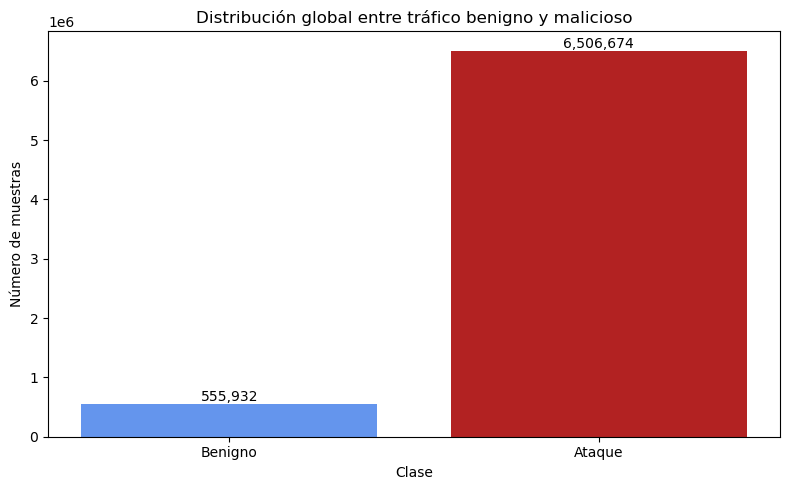

In [18]:
# Distribución global benign/malicious

# Resumen por clase
class_summary = pd.DataFrame({
    "Clase": ["Benigno", "Ataque"],
    "Muestras": [
        file_catalog_df.loc[~file_catalog_df["is_attack"], "n_samples"].sum(),
        file_catalog_df.loc[file_catalog_df["is_attack"], "n_samples"].sum()
    ],
    "Porcentaje": [
        file_catalog_df.loc[~file_catalog_df["is_attack"], "n_samples"].sum() / n_samples * 100,
        file_catalog_df.loc[file_catalog_df["is_attack"], "n_samples"].sum() / n_samples * 100
    ]
})

# Tabla
display(class_summary)

# Gráfica
plt.figure(figsize=(8, 5))
bars = plt.bar(
    class_summary["Clase"],
    class_summary["Muestras"],
    color=["cornflowerblue", "firebrick"]
)

plt.title("Distribución global entre tráfico benigno y malicioso")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")

# Etiquetas sobre las barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

En la Figura anterior se muestra la distribución de las muestras entre tráfico benigno y tráfico malicioso. De dicha Figura se pueden extraer las siguientes conclusiones:

- **Hay muchas más muestras relacionadas con ataques que con tráfico benigno**. De hecho, las muestras relacionadas con el tráfico benigno engloban apenas un 8% de las muestras totales, mientas que las muestras relacionadas con el tráfico de dispositivos infectados representan aproximadamente un 92% del total de muestras.

- En realidad, el dataset está formado por 10 combinaciones distintas de familia de ataque + tipo de ataque. Por tanto, es normal que el número de muestras benigno sea aproximadamente 11 veces menor que el número de muestras de ataque. En realidad, esto podría suponer que cada combinación de familia de ataque + muestra de ataque tendría aproximadamente el mismo número de muestras que el grupo de las benignas. Esto es una hipótesis que se evaluará en las siguientes celdas.

La gráfica de la Figura anterior expone una peculiaridad que debe tener nuestro entrenamiento respecto los procesos de entrenamiento habituales en ML. Esta peculiaridad se basa en que las soluciones que hemos planteado requieren un entrenamiento sobre muestras benignas para que los modelos sean robustos ante ataques no vistos previamente. Por tanto, en nuestro caso el conjunto de entrenamiento y validación será mucho menor que el conjunto de evaluación. 

Esto se debe a que las muestras de entrenamiento y validación deben pertenecer al conjunto de muestras benignas mientas que las muestras de evaluación deben tener muestras de las 2 clases.

,Dispositivo,Muestras benignas,Muestras de ataque
0,1. Danmini_Doorbell,49548,968750
1,2. Ecobee_Thermostat,13113,822763
2,3. Ennio_Doorbell,39100,316400
3,4. Philips_B120N10_Baby_Monitor,175240,923437
4,5. Provision_PT_737E_Security_Camera,62154,766106
5,6. Provision_PT_838_Security_Camera,98514,738377
6,7. Samsung_SNH_1011_N_Webcam,52150,323072
7,8. SimpleHome_XCS7_1002_WHT_Security_Camera,46585,816471
8,9. SimpleHome_XCS7_1003_WHT_Security_Camera,19528,831298


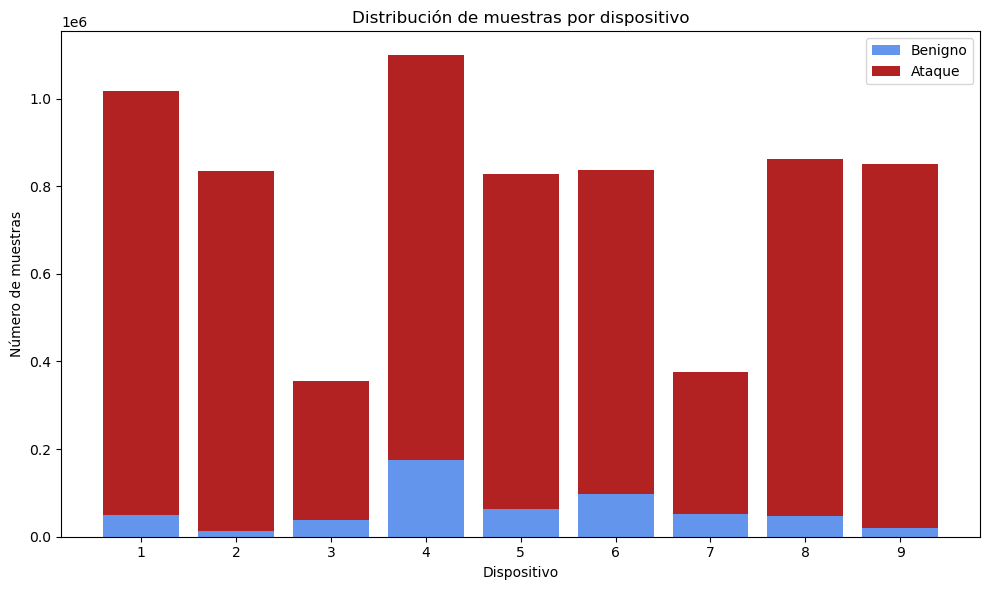

In [32]:
# Distribución por dispositivo

# Resumen por dispositivo y clase
device_summary = (
    file_catalog_df
    .groupby(["device", "device_name", "is_attack"])["n_samples"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

device_summary.columns = [
    "device",
    "device_name",
    "n_samples_benign",
    "n_samples_attack"
]

# Etiqueta para la tabla y el eje X
device_summary["device_label"] = (
    device_summary["device"].astype(str)
    + ". "
    + device_summary["device_name"]
)

# Tabla resumen
table_df = device_summary[
    ["device_label", "n_samples_benign", "n_samples_attack"]
].rename(
    columns={
        "device_label": "Dispositivo",
        "n_samples_benign": "Muestras benignas",
        "n_samples_attack": "Muestras de ataque"
    }
)

display(table_df)

# Gráfica de barras apiladas
plt.figure(figsize=(10, 6))

plt.bar(
    device_summary["device"],
    device_summary["n_samples_benign"],
    color="cornflowerblue",
    label="Benigno"
)

plt.bar(
    device_summary["device"],
    device_summary["n_samples_attack"],
    bottom=device_summary["n_samples_benign"],
    color="firebrick",
    label="Ataque"
)

plt.title("Distribución de muestras por dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Número de muestras")
plt.xticks(device_summary["device"])
plt.legend()

plt.tight_layout()
plt.show()

En la Figura anterior se puede apreciar que tanto el timbre inteligente de la marca Ennio (dispotivo 3), como la webcam de Samsung (dispositivo 7) tienen menos muestras de ataque de lo normal. Esto puede indicar que alguna familia o tipo de ataque no se ha ejecutado sobre los dispositivos mencionados. Esta casuística sería comprensible puesto que no todos los dispositivos son vulnerables a los mismos ataques.

Además, se puede observar que el monitor de bebé (dispositivo 4) tiene muchas más muestras benignas que el resto de dispositivos. Este comportamiento es normal puesto que los dispositivos IoT están pensados para cubrir tareas muy diversas y por tanto es normal que la cantidad de tráfico que genera cada uno de ellos sea distinta. De hecho, mantener estas distribuciones desbalanceadas en evaluación puede ayudar a simular un entorno más parecido a lo que sería el comportamiento en producción de las redes de dispositivos IoT.

,Familia de ataque,Número de muestras,Porcentaje
0,gafgyt,2838272,43.620934
1,mirai,3668402,56.379066


,Ataque,Número de muestras
0,gafgyt.combo,515156
1,gafgyt.junk,261789
2,gafgyt.scan,255111
3,gafgyt.tcp,859850
4,gafgyt.udp,946366
5,mirai.ack,643821
6,mirai.scan,537979
7,mirai.syn,733299
8,mirai.udp,1229999
9,mirai.udpplain,523304


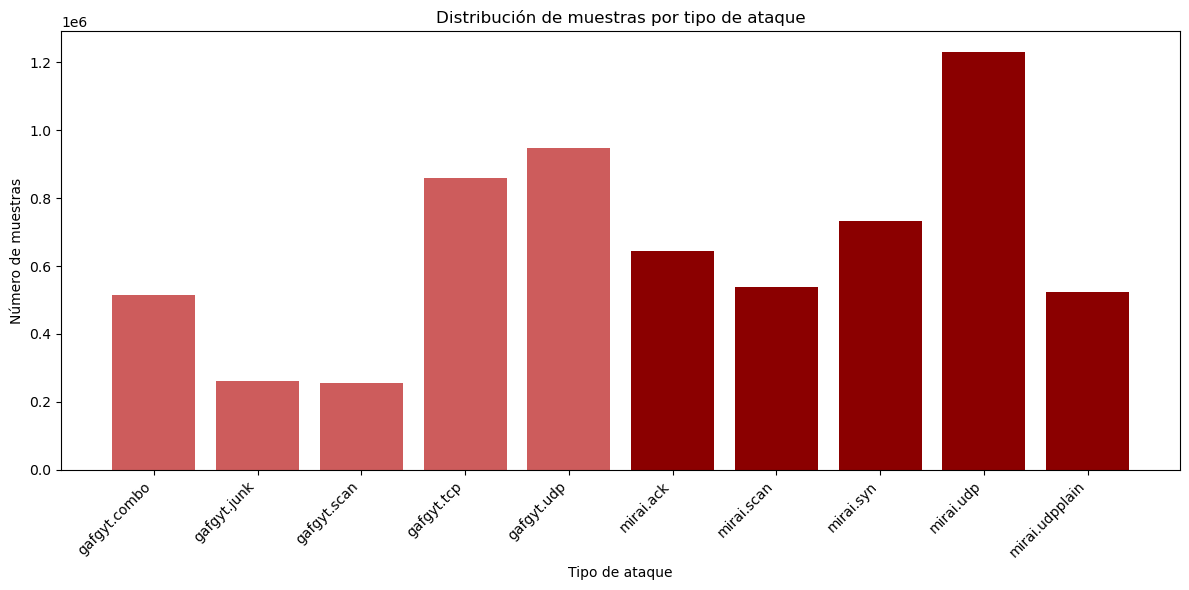

In [19]:
# Distribución por familia y tipo de ataque

# Tabla de muestras por familia de ataque
family_summary_df = (
    file_catalog_df[file_catalog_df["is_attack"]]
    .groupby("diagnostic")["n_samples"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "diagnostic": "Familia de ataque",
            "n_samples": "Número de muestras"
        }
    )
)
family_summary_df["Porcentaje"] = (
    family_summary_df["Número de muestras"] / family_summary_df["Número de muestras"].sum() * 100
)

display(family_summary_df)


# Tabla de muestras por tipo de ataque concreto
attack_summary_df = (
    file_catalog_df[file_catalog_df["is_attack"]]
    .groupby(["diagnostic", "attack_type"])["n_samples"]
    .sum()
    .reset_index()
)

attack_summary_df["Ataque"] = (
    attack_summary_df["diagnostic"]
    + "."
    + attack_summary_df["attack_type"]
)

attack_summary_df = (
    attack_summary_df[
        ["Ataque", "n_samples"]
    ]
    .rename(
        columns={
            "n_samples": "Número de muestras"
        }
    )
)

display(attack_summary_df)


# Gráfica
plot_df = (
    file_catalog_df[file_catalog_df["is_attack"]]
    .groupby(["diagnostic", "attack_type"])["n_samples"]
    .sum()
    .reset_index()
)

plot_df["Ataque"] = (
    plot_df["diagnostic"]
    + "."
    + plot_df["attack_type"]
)

colors = [
    "#CD5C5C",  # indianred
    "#CD5C5C",  # indianred
    "#CD5C5C",  # indianred
    "#CD5C5C",  # indianred
    "#CD5C5C",  # indianred
    "#8B0000",    # darkred
    "#8B0000",    # darkred
    "#8B0000",    # darkred
    "#8B0000",    # darkred
    "#8B0000",    # darkred
]

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["Ataque"],
    plot_df["n_samples"],
    color=colors
)

plt.title("Distribución de muestras por tipo de ataque")
plt.xlabel("Tipo de ataque")
plt.ylabel("Número de muestras")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

De la gráfica anterior se pueden sacar las siguientes conclusiones:

- **La distribución de muestras entre las 2 familias de ataques está ligeramente descompensada. La familia de ataque *Mirai* tiene un 12% más de muestras que la familia de ataque *Gafgyt*.**

- El tipo de ataque que más muestras tiene en las 2 familias es *UDP*. *UDP* es un protocolo de red utilizado para la transmisión rápida y directa de paquetes. Seguramente este tipo de ataque sea el que más muestras tiene porque se basa en el envío de mensajes sin establecer una comunicación previa entre el emisor y el resceptor. Este último punto es una explicación hipotética de este pico de muestras que no puede ser probada.

- El número de muestras medio de cada combinación de familia de ataque + tipo de ataque es similar al número de muestras benignas, tal y como se hipotetizó en las primeras celdas de este apartado.

diagnostic,Dispositivo,Muestras benignas,Muestras Gafgyt,Muestras Mirai
0,1. Danmini_Doorbell,49548,316650,652100
1,2. Ecobee_Thermostat,13113,310630,512133
2,3. Ennio_Doorbell,39100,316400,0
3,4. Philips_B120N10_Baby_Monitor,175240,312723,610714
4,5. Provision_PT_737E_Security_Camera,62154,330096,436010
5,6. Provision_PT_838_Security_Camera,98514,309040,429337
6,7. Samsung_SNH_1011_N_Webcam,52150,323072,0
7,8. SimpleHome_XCS7_1002_WHT_Security_Camera,46585,303223,513248
8,9. SimpleHome_XCS7_1003_WHT_Security_Camera,19528,316438,514860


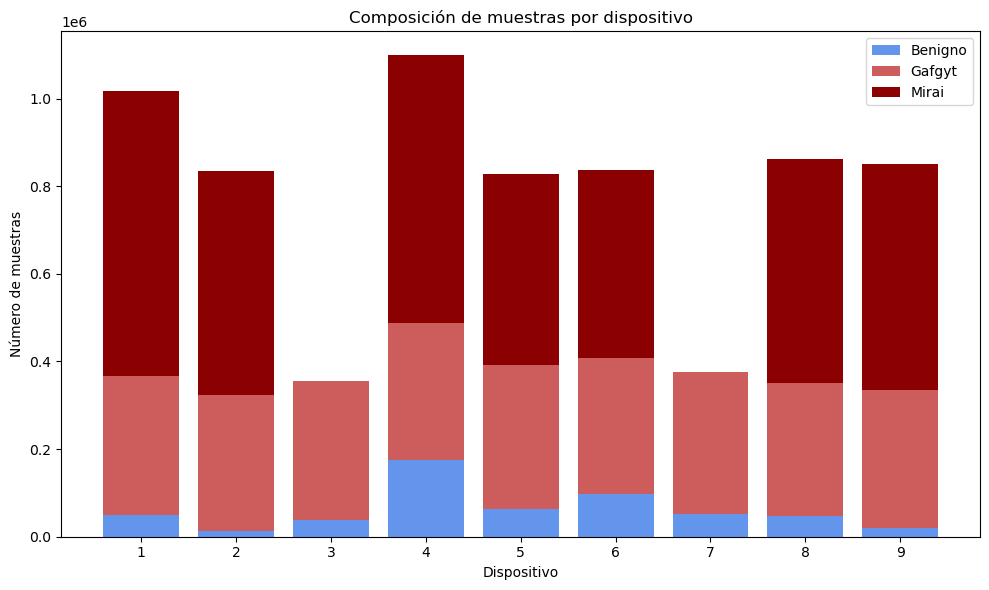

In [ ]:
# Tabla
device_composition_df = (
    file_catalog_df
    .groupby(["device", "device_name", "diagnostic"], sort=False)["n_samples"]
    .sum()
    .reset_index()
)

device_composition_table = (
    device_composition_df
    .pivot_table(
        index=["device", "device_name"],
        columns="diagnostic",
        values="n_samples",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
)

device_composition_table["Dispositivo"] = (
    device_composition_table["device"].astype(str)
    + ". "
    + device_composition_table["device_name"]
)

device_composition_table = (
    device_composition_table[
        ["Dispositivo", "benign", "gafgyt", "mirai"]
    ]
    .rename(
        columns={
            "benign": "Muestras benignas",
            "gafgyt": "Muestras Gafgyt",
            "mirai": "Muestras Mirai"
        }
    )
)

display(device_composition_table)

# Gráfica
plot_df = (
    device_composition_table
    .copy()
)

device_ids = (
    plot_df["Dispositivo"]
    .str.split(".")
    .str[0]
    .astype(int)
)

plt.figure(figsize=(10, 6))

# Benigno
plt.bar(
    device_ids,
    plot_df["Muestras benignas"],
    color="cornflowerblue",
    label="Benigno"
)

# Gafgyt
plt.bar(
    device_ids,
    plot_df["Muestras Gafgyt"],
    bottom=plot_df["Muestras benignas"],
    color="#CD5C5C",
    label="Gafgyt"
)

# Mirai
plt.bar(
    device_ids,
    plot_df["Muestras Mirai"],
    bottom=(
        plot_df["Muestras benignas"]
        + plot_df["Muestras Gafgyt"]
    ),
    color="#8B0000",
    label="Mirai"
)

plt.title("Composición de muestras por dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Número de muestras")

plt.xticks(device_ids)
plt.legend()

plt.tight_layout()
plt.show()

En la Figura anterior se pueden apreciar varios puntos:
- Tal y como pasaba en la gráfica de la distribución por dispositivo, el monitor de bebé (dispositivo 4) es el dispositivo con una distribución más distinta al resto de dispositivos. De hecho es el aparato con mayor número de muestras benignas de los 9.

- Los dispositivos que son del mismo tipo prsentan distribuciones similares.

- El timbre inteligente de la marca Ennio (dispositivo 3) y la webcam de samsung no tienen muestras de paquetes infectados con la familia de ataque Mirai. Esto llama la atención porque aun así, globalmente hay más muestras de la familia Mirai que de la familia Gafgyt. Esto demuestra que por dispositivo el desbalance entre ambas familias de ataque es mayor cuando las 2 están presentes.

## 2. Calidad y consistencia de los datos


Una vez descrita la estructura del dataset, se revisa su calidad. Esta parte es importante antes de realizar análisis estadístico avanzado o entrenar modelos, porque valores faltantes, duplicados, variables constantes, escalas heterogéneas o correlaciones muy fuertes pueden afectar de forma directa al modelado.

Debido a la magnitud del dataset se van a extraer 2 tipos de muestra para su análisis:
- Muestra de todo el dataset
- Muestra de cada uno de los dispositivos

In [ ]:
# Creación de muestra estratificada del dataset completo para EDA
sample_global_dataset(
    input_dir=PROCESSED_TEMP_PATH,
    output_dir=PROCESSED_TEMP_PATH,
    device_ids=list(range(1, 10)),
    sample_frac=EDA_GLOBAL_SAMPLE_RATIO,
    random_state=RANDOM_STATE,
)

# Creación de muestras estratificadas por dispositivo para EDA
for device_id in range(1, 10):
    sample_device_dataset(
        input_dir=PROCESSED_TEMP_PATH,
        output_dir=PROCESSED_TEMP_PATH,
        device_id=device_id,
        sample_frac=EDA_DEVICE_SAMPLE_RATIO,
        random_state=RANDOM_STATE,
    )

In [14]:
# Ruta a la muestra global del dataset para EDA
GLOBAL_SAMPLE_PATH = Path(PROCESSED_TEMP_PATH) / "global_sample.parquet"

# Ruta a las muestras por dispositivo para EDA
DEVICE_SAMPLE_PATHS = [Path(PROCESSED_TEMP_PATH) / f"device_{device_id}_sample.parquet" for device_id in range(1, 10)]

### 2.1 Valores faltantes

Se comprueba la presencia de valores nulos en una muestra estratificada de todo el dataset. Esta comprobación permite detectar problemas de completitud sin cargar simultáneamente todo el dataset en memoria.

Además, en caso de existir valores faltantes en alguna de las *features*, se hace un análisis por dispositivo para saber más acerca del posible origen del problema.

In [ ]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:
    missing_summary_df = (
        global_sample_df
        .isna()
        .sum()
        .reset_index()
    )

    missing_summary_df.columns = ["Variable", "Valores faltantes"]

    missing_summary_df["Porcentaje faltante"] = (
        missing_summary_df["Valores faltantes"] / len(global_sample_df) * 100
    )

    missing_summary_df = missing_summary_df.sort_values(
        "Porcentaje faltante",
        ascending=False
    )

    display(missing_summary_df)

    print(
        f"Porcentaje total de valores faltantes: "
        f"{global_sample_df.isna().mean().mean() * 100:.4f}%"
    )

,Variable,Valores faltantes,Porcentaje faltante
0,MI_dir_L5_weight,0,0.0
1,MI_dir_L5_mean,0,0.0
2,MI_dir_L5_variance,0,0.0
3,MI_dir_L3_weight,0,0.0
4,MI_dir_L3_mean,0,0.0
5,MI_dir_L3_variance,0,0.0
6,MI_dir_L1_weight,0,0.0
7,MI_dir_L1_mean,0,0.0
8,MI_dir_L1_variance,0,0.0
9,MI_dir_L0.1_weight,0,0.0


Porcentaje total de valores faltantes: 0.0000%


Como se puede observar en la celda de código anterior, **no existe ninguna muestra con algún valor nulo en el dataset.** Esto tiene sentido puesto que las muestras no representan el tráfico en crudo de la red, donde quizás algún dato podría no haberse capturado por el gran volumen de información que se suele manejar. Lo que representan las muestras son estadísticos del tráfico, por tanto, el preprocesado que se le ha aplicado al tráfico en crudo de la red ha servido para que no existan valores nulos en el dataset público de N-BaIoT.

### 2.2 Redundancia de las muestras

El análisis de la redundancia de las muestras tiene como objetivo estudiar el grado de repetición existente en el conjunto de datos desde distintas perspectivas. Dependiendo del escenario considerado, el concepto de muestra duplicada puede variar, ya que un mismo vector de características puede corresponder a dispositivos o tipos de tráfico diferentes.

Por este motivo, este apartado se divide en tres análisis complementarios, cada uno orientado a responder una pregunta concreta relacionada con la calidad del dataset o con los escenarios experimentales evaluados posteriormente en este trabajo.

In [16]:
def get_duplicate_mask(df: pd.DataFrame, subset: list[str]) -> pd.Series:
    """
    Devuelve una máscara booleana indicando las muestras duplicadas
    según las columnas indicadas en subset.
    """
    return df.duplicated(subset=subset, keep=False)


def build_duplicate_summary(
    df: pd.DataFrame,
    duplicate_mask: pd.Series,
    group_columns: list[str],
) -> pd.DataFrame:
    """
    Construye una tabla resumen de duplicados por grupo.
    """

    summary_df = (
        df.assign(is_duplicate=duplicate_mask)
        .groupby(group_columns, sort=False)
        .agg(
            Muestras=("is_duplicate", "size"),
            Duplicados=("is_duplicate", "sum")
        )
        .reset_index()
    )

    summary_df["Porcentaje duplicados"] = (
        summary_df["Duplicados"] / summary_df["Muestras"] * 100
    )

    summary_df["Dispositivo + Familia"] = (
        "device_"
        + summary_df["device"].astype(str)
        + " - "
        + summary_df["attack_family"].astype(str)
    )

    summary_df = summary_df[
        [
            "Dispositivo + Familia",
            "Muestras",
            "Duplicados",
            "Porcentaje duplicados",
        ]
    ]

    total_samples = summary_df["Muestras"].sum()
    total_duplicates = summary_df["Duplicados"].sum()

    summary_df.loc[len(summary_df)] = {
        "Dispositivo + Familia": "Total",
        "Muestras": total_samples,
        "Duplicados": total_duplicates,
        "Porcentaje duplicados": total_duplicates / total_samples * 100,
    }

    summary_df["Porcentaje duplicados"] = (
        summary_df["Porcentaje duplicados"].round(2)
    )

    return summary_df


def plot_duplicate_summary(
    duplicates_summary_df: pd.DataFrame,
    title: str = "Porcentaje de muestras duplicadas por dispositivo y clase",
) -> None:
    """
    Grafica el porcentaje de muestras duplicadas por dispositivo y familia.

    Espera una tabla generada por build_duplicate_summary(), con las columnas:
    - "Dispositivo + Familia"
    - "Porcentaje duplicados"
    """

    plot_df = duplicates_summary_df[
        duplicates_summary_df["Dispositivo + Familia"] != "Total"
    ].copy()

    plot_df[["Dispositivo", "Familia"]] = (
        plot_df["Dispositivo + Familia"]
        .str.split(" - ", expand=True)
    )

    plot_df = (
        plot_df
        .pivot(
            index="Dispositivo",
            columns="Familia",
            values="Porcentaje duplicados"
        )
        .reset_index()
    )

    plot_df["device_id"] = (
        plot_df["Dispositivo"]
        .str.replace("device_", "", regex=False)
        .astype(int)
    )

    plot_df = plot_df.sort_values("device_id")

    x = np.arange(len(plot_df))
    bar_width = 0.25

    plt.figure(figsize=(11, 6))

    plt.bar(
        x - bar_width,
        plot_df["benign"],
        width=bar_width,
        color="cornflowerblue",
        label="Benigno"
    )

    plt.bar(
        x,
        plot_df["gafgyt"],
        width=bar_width,
        color="#CD5C5C",
        label="Gafgyt"
    )

    plt.bar(
        x + bar_width,
        plot_df["mirai"],
        width=bar_width,
        color="#8B0000",
        label="Mirai"
    )

    plt.title(title)
    plt.xlabel("Dispositivo")
    plt.ylabel("Porcentaje de muestras duplicadas (%)")

    plt.xticks(
        x,
        plot_df["device_id"]
    )

    plt.ylim(0, 100)

    plt.legend()
    plt.tight_layout()
    plt.show()

#### 2.2.1 Duplicados en el dataset público

En primer lugar, se analiza si el dataset público N-BaIoT contiene registros duplicados como consecuencia de su proceso de construcción. Para ello, se consideran tanto las características de cada muestra como sus metadatos asociados (dispositivo, familia de ataque y tipo de ataque), de forma que únicamente se consideren duplicados aquellos registros completamente idénticos.

,Dispositivo + Familia,Muestras,Duplicados,Porcentaje duplicados
0,device_1 - benign,24717,5067,20.50
1,device_1 - gafgyt,158146,6219,3.93
2,device_1 - mirai,326286,0,0.00
3,device_2 - benign,6464,2,0.03
4,device_2 - gafgyt,155419,6306,4.06
5,device_2 - mirai,256055,0,0.00
6,device_3 - benign,19487,2142,10.99
7,device_3 - gafgyt,158263,6767,4.28
8,device_4 - benign,87448,5783,6.61
9,device_4 - gafgyt,156198,6315,4.04


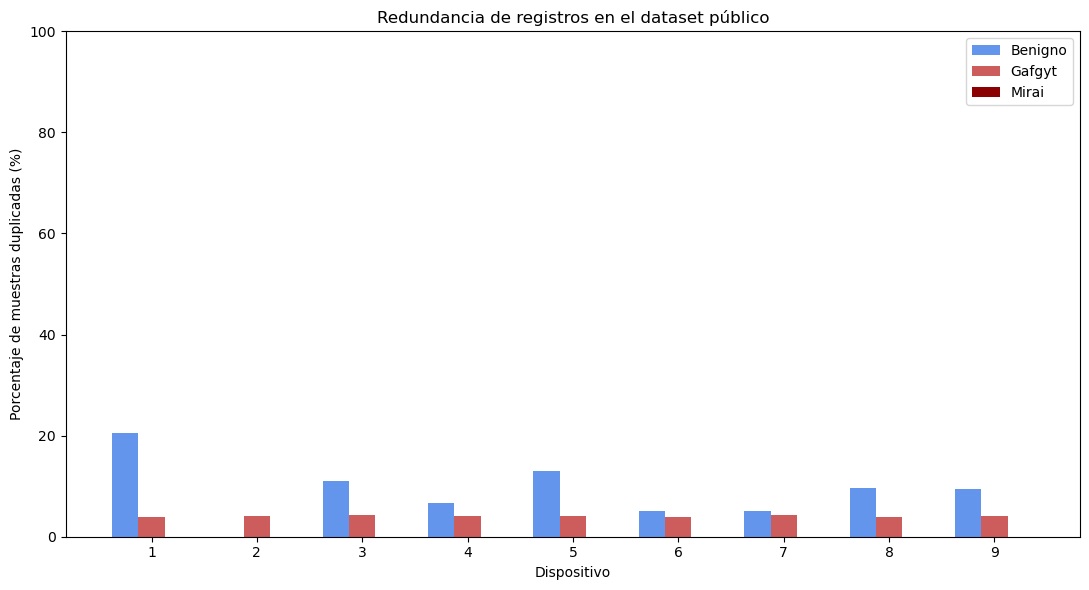

In [17]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    duplicate_subset = (
        NUMERIC_COLUMNS
        + ["device", "attack_family", "attack_type"]
    )

    duplicate_mask = get_duplicate_mask(
        df=global_sample_df,
        subset=duplicate_subset
    )

    duplicates_summary_df = build_duplicate_summary(
        df=global_sample_df,
        duplicate_mask=duplicate_mask,
        group_columns=["device", "attack_family"]
    )

    display(duplicates_summary_df)

    plot_duplicate_summary(
        duplicates_summary_df,
        title="Redundancia de registros en el dataset público"
    )

En la tabla anterior se observa que el porcentaje de registros duplicados es reducido en todos los dispositivos y familias de ataque, siendo especialmente bajo en el tráfico de ataque. Estos resultados indican que el dataset público N-BaIoT apenas contiene registros completamente idénticos cuando se consideran conjuntamente las características y los metadatos asociados a cada muestra. Por tanto, no se aprecia la existencia de un problema significativo de duplicación derivado del proceso de construcción del dataset.

#### 2.2.2 Duplicados en el escenario de entrenamiento por dispositivo

A continuación, se estudia el grado de redundancia presente en los conjuntos de datos utilizados para entrenar los modelos específicos por dispositivo. En este caso, los duplicados se identifican considerando únicamente las características y el dispositivo al que pertenece cada muestra, reproduciendo así el escenario al que se enfrentan estos modelos durante el entrenamiento.


,Dispositivo + Familia,Muestras,Duplicados,Porcentaje duplicados
0,device_1 - benign,24717,5067,20.50
1,device_1 - gafgyt,158146,6219,3.93
2,device_1 - mirai,326286,0,0.00
3,device_2 - benign,6464,2,0.03
4,device_2 - gafgyt,155419,6306,4.06
5,device_2 - mirai,256055,0,0.00
6,device_3 - benign,19487,2142,10.99
7,device_3 - gafgyt,158263,6767,4.28
8,device_4 - benign,87448,5783,6.61
9,device_4 - gafgyt,156198,6315,4.04


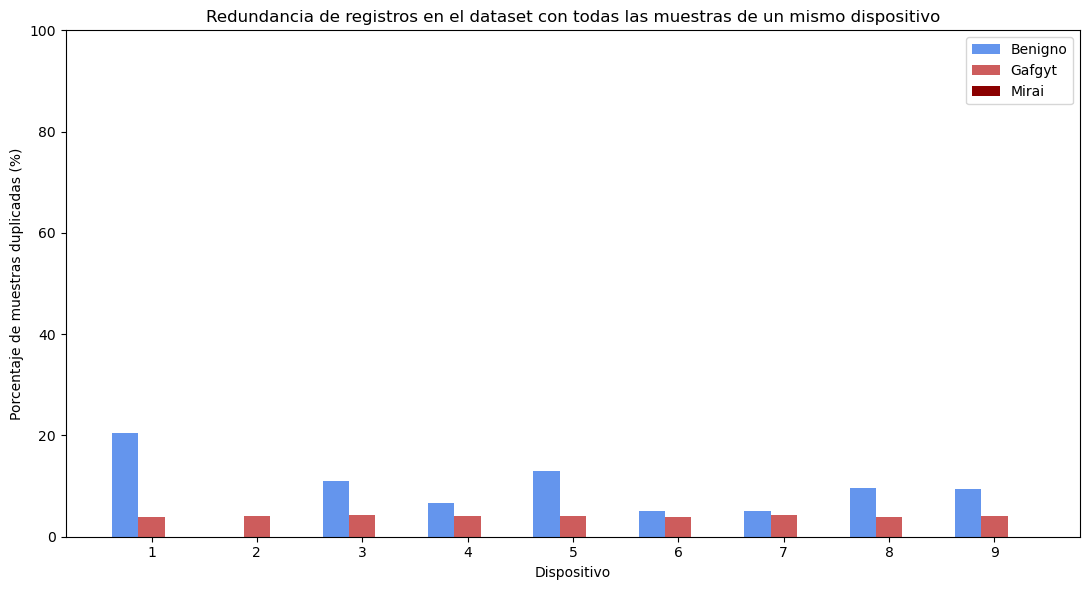

In [20]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    duplicate_subset = NUMERIC_COLUMNS + ["device"]

    duplicate_mask = get_duplicate_mask(
        df=global_sample_df,
        subset=duplicate_subset
    )

    duplicates_summary_df = build_duplicate_summary(
        df=global_sample_df,
        duplicate_mask=duplicate_mask,
        group_columns=["device", "attack_family"]
    )

    display(duplicates_summary_df)

    plot_duplicate_summary(
        duplicates_summary_df,
        title="Redundancia de registros en el dataset con todas las muestras de un mismo dispositivo"
    )

Los resultados obtenidos son idénticos a los del apartado anterior. Esto indica que, dentro de un mismo dispositivo, las muestras que comparten exactamente el mismo vector de características también pertenecen a la misma familia y tipo de tráfico. En otras palabras, no se han encontrado evidencias de que existan muestras con idénticas características pero diferentes etiquetas dentro de un mismo dispositivo. Desde el punto de vista de los modelos específicos por dispositivo, esto sugiere que el grado de redundancia de los datos de entrenamiento es reducido.

#### 2.2.3 Duplicados en el escenario de entrenamiento global

Por último, se analiza la redundancia existente en el conjunto de datos utilizado para entrenar los modelos globales. En este escenario, el dispositivo deja de formar parte de la definición de una muestra duplicada, ya que el modelo recibe conjuntamente datos procedentes de todos los dispositivos. Por ello, los duplicados se identifican considerando exclusivamente las características de cada muestra.

En los tres análisis, una vez identificadas las muestras duplicadas, se estudia su distribución utilizando los metadatos del dataset con el objetivo de comprender mejor el origen de dicha redundancia y su posible influencia sobre los experimentos realizados posteriormente.

,Dispositivo + Familia,Muestras,Duplicados,Porcentaje duplicados
0,device_1 - benign,24717,5067,20.50
1,device_1 - gafgyt,158146,155909,98.59
2,device_1 - mirai,326286,152265,46.67
3,device_2 - benign,6464,2,0.03
4,device_2 - gafgyt,155419,153867,99.00
5,device_2 - mirai,256055,186038,72.66
6,device_3 - benign,19487,2143,11.00
7,device_3 - gafgyt,158263,156498,98.88
8,device_4 - benign,87448,5783,6.61
9,device_4 - gafgyt,156198,155022,99.25


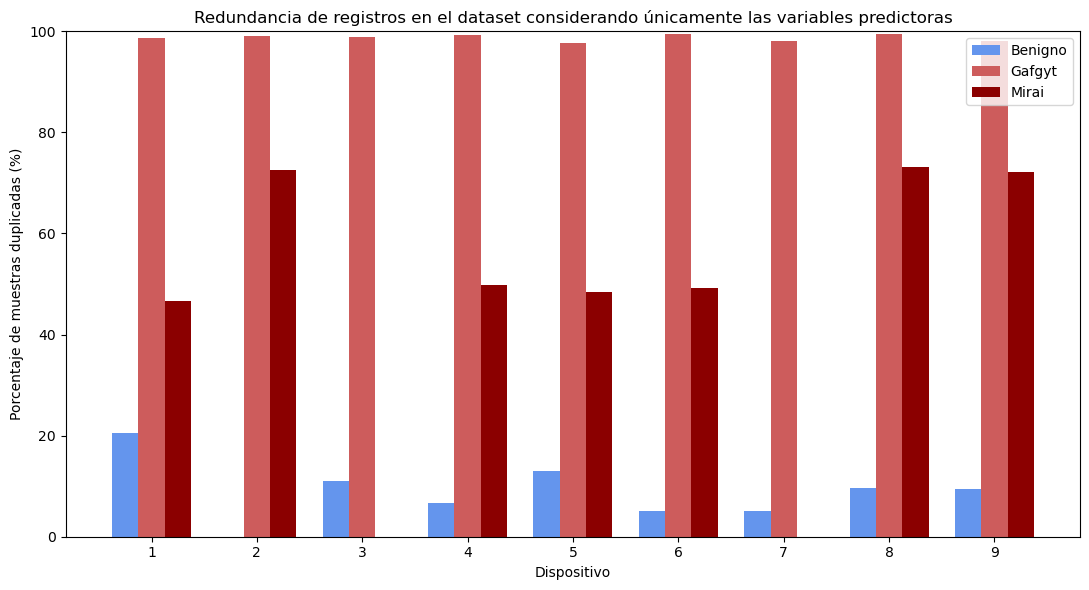

In [19]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    duplicate_mask = get_duplicate_mask(
        df=global_sample_df,
        subset=NUMERIC_COLUMNS
    )

    duplicates_summary_df = build_duplicate_summary(
        df=global_sample_df,
        duplicate_mask=duplicate_mask,
        group_columns=["device", "attack_family"]
    )

    display(duplicates_summary_df)

    plot_duplicate_summary(
        duplicates_summary_df,
        title="Redundancia de registros en el dataset considerando únicamente las variables predictoras"
    )

A diferencia de los apartados anteriores, al considerar únicamente las características de las muestras el porcentaje de duplicados aumenta de forma muy notable. Este comportamiento pone de manifiesto que existen numerosos vectores de características compartidos entre dispositivos distintos, especialmente en el tráfico de ataque. Por tanto, aunque el dataset presenta una baja redundancia a nivel de registros y en el entrenamiento por dispositivo, los modelos globales se enfrentan a un conjunto de datos con una redundancia considerablemente mayor al integrar el tráfico procedente de todos los dispositivos de la red.

### 2.3 Features constantes y baja varianza

La variabilidad de una característica determina la cantidad de información que puede aportar durante el entrenamiento de un modelo de aprendizaje automático. Mientras que una característica constante no contiene capacidad discriminativa, una característica con una variabilidad reducida puede aportar una cantidad limitada de información dependiendo del contexto y del algoritmo empleado.

Por este motivo, este apartado se divide en 2 análisis complementarios. En primer lugar, se estudia la existencia de características constantes, cuya identificación es objetiva al no presentar ninguna variabilidad. Posteriormente, se analiza la distribución de la varianza del conjunto de características con el objetivo de determinar si existe un grupo claramente diferenciado de variables cuya variabilidad sea significativamente inferior a la del resto y, por tanto, valorar si resulta justificado aplicar un filtrado por baja varianza durante el preprocesamiento.

#### 2.3.1 Features constantes

En este subapartado se analiza si existen características que mantienen un valor constante en todas las muestras del dataset. Este tipo de variables no aportan información durante el entrenamiento de los modelos y, en caso de existir, podrían eliminarse sin pérdida de información.

In [ ]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:
    feature_variances = global_sample_df[NUMERIC_COLUMNS].var()
    print("Número de variables constantes:", (feature_variances == 0).sum())

Número de variables con varianza cero: 0


Como se puede observar no hay características constantes.

#### 2.3.2 Análisis de la varianza de las características

A continuación, se estudia la distribución de la varianza de las características con el objetivo de evaluar su nivel de variabilidad relativo. A diferencia de las características constantes, no existe un umbral universal para determinar cuándo una característica presenta una varianza suficientemente baja como para ser eliminada. Por ello, este análisis permite valorar, a partir de la distribución observada, si resulta conveniente aplicar un filtrado por baja varianza durante el preprocesamiento.

,Feature,Varianza
0,HpHp_L5_pcc,0.001288
1,HH_L5_pcc,0.001290
2,HpHp_L3_pcc,0.001463
3,HH_L3_pcc,0.001498
4,HpHp_L1_pcc,0.001872
5,HH_L1_pcc,0.002112
6,HpHp_L0.1_pcc,0.002735
7,HpHp_L0.01_pcc,0.003391
8,HH_L0.1_pcc,0.004223
9,HH_L0.01_pcc,0.006319


,Feature,Varianza
95,H_L5_variance,5.810976e+08
96,MI_dir_L5_variance,5.810976e+08
97,H_L3_variance,6.342483e+08
98,MI_dir_L3_variance,6.342483e+08
99,H_L1_variance,6.806385e+08
100,MI_dir_L1_variance,6.806385e+08
101,H_L0.01_variance,6.871355e+08
102,MI_dir_L0.01_variance,6.871379e+08
103,H_L0.1_variance,6.947465e+08
104,MI_dir_L0.1_variance,6.947475e+08


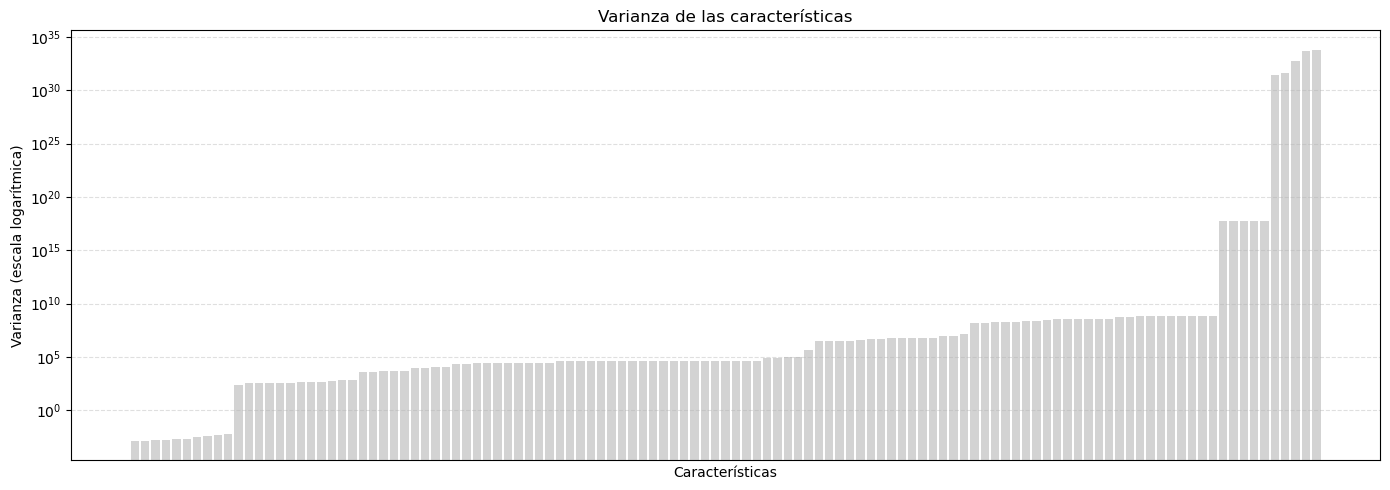

In [15]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    feature_variances = (
        global_sample_df[NUMERIC_COLUMNS]
        .var()
        .sort_values()
    )

    feature_variance_df = pd.DataFrame({
        "Feature": feature_variances.index,
        "Varianza": feature_variances.values
    })

    display(feature_variance_df.head(20))

    display(feature_variance_df.tail(20))

    plt.figure(figsize=(14, 5))

    plt.bar(
        feature_variance_df["Feature"],
        feature_variance_df["Varianza"],
        color="lightgray"
    )

    plt.yscale("log")

    plt.title("Varianza de las características")
    plt.xlabel("Características")
    plt.ylabel("Varianza (escala logarítmica)")

    plt.xticks([])

    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [17]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:
    variances = global_sample_df[NUMERIC_COLUMNS].var()
    low_var_features = variances[variances < 1].index

    low_var_df = global_sample_df[low_var_features].describe()

    display(low_var_df)

,HH_L5_pcc,HH_L3_pcc,HH_L1_pcc,HH_L0.1_pcc,HH_L0.01_pcc,HpHp_L5_pcc,HpHp_L3_pcc,HpHp_L1_pcc,HpHp_L0.1_pcc,HpHp_L0.01_pcc
count,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06,3.531303e+06
mean,-2.288838e-04,-2.406084e-04,6.540721e-05,3.129339e-03,7.330964e-03,1.634745e-03,1.696722e-03,1.669197e-03,1.888390e-03,2.917728e-03
std,3.591587e-02,3.870861e-02,4.596123e-02,6.498625e-02,7.949264e-02,3.588621e-02,3.824579e-02,4.326469e-02,5.229896e-02,5.823417e-02
min,-1.486384e+00,-1.586222e+00,-1.608383e+00,-1.586467e+00,-1.691354e+00,-1.220216e+00,-1.351988e+00,-1.476414e+00,-1.586467e+00,-2.252107e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.002652e+00,2.197596e+00,2.422158e+00,2.638301e+00,2.685264e+00,2.075581e+00,2.293738e+00,2.546912e+00,2.742068e+00,2.792586e+00


Los resultados obtenidos muestran que no existen características constantes y, por tanto, ninguna variable puede considerarse completamente carente de información. Por otro lado, aunque la distribución de las varianzas revela la existencia de un pequeño grupo de características con una variabilidad notablemente inferior al resto, dicho comportamiento se concentra exclusivamente en las variables asociadas al coeficiente de correlación de Pearson (`*_pcc`). Dado que estas características presentan una naturaleza distinta al resto de variables del dataset y una elevada concentración de valores nulos, no se considera que este resultado constituya, por sí solo, una evidencia suficiente para justificar la aplicación de un filtrado por baja varianza.

Asimismo, el análisis pone de manifiesto la existencia de diferencias de varios órdenes de magnitud entre las varianzas de las distintas características. Aunque la varianza depende tanto de la dispersión de los datos como de la escala de la variable, este comportamiento sugiere que las características del dataset podrían presentar escalas muy heterogéneas. En el siguiente apartado se analizará específicamente la distribución de escalas de las variables con el objetivo de comprobar esta hipótesis y determinar si resulta necesario aplicar un proceso de escalado antes del entrenamiento de los modelos.

### 2.4 Distribución de escalas

En el apartado anterior se observó que las varianzas de las características presentan diferencias de varios órdenes de magnitud. Este resultado sugiere que las variables podrían encontrarse en escalas muy distintas, lo cual es especialmente relevante porque los modelos considerados posteriormente pueden verse afectados por la magnitud de las variables de entrada.

El objetivo de este apartado es comprobar si existen diferencias significativas de escala entre las características del dataset y valorar si resulta necesario aplicar un proceso de escalado antes del entrenamiento de los modelos. Para ello, se analiza tanto el rango total de cada variable (`max - min`) como su rango intercuartílico (`Q3 - Q1`). El primero permite estudiar la escala completa de cada característica, mientras que el segundo permite observar la dispersión habitual de los valores reduciendo la influencia de posibles valores extremos.

A partir de estos resultados se discutirá qué tipo de escalado resulta más adecuado para el problema considerado y para los modelos que se evaluarán posteriormente.

ESTUDIO DEL RANGO DE LAS CARACTERÍSTICAS
Top 20 características con menor rango:


,Feature,min,max,Rango
0,HpHp_L5_pcc,-1.220216,2.075581,3.295797
1,HH_L5_pcc,-1.486384,2.002652,3.489036
2,HpHp_L3_pcc,-1.351988,2.293738,3.645726
3,HH_L3_pcc,-1.586222,2.197596,3.783817
4,HpHp_L1_pcc,-1.476414,2.546912,4.023326
5,HH_L1_pcc,-1.608383,2.422158,4.030541
6,HH_L0.1_pcc,-1.586467,2.638301,4.224768
7,HpHp_L0.1_pcc,-1.586467,2.742068,4.328535
8,HH_L0.01_pcc,-1.691354,2.685264,4.376618
9,HpHp_L0.01_pcc,-2.252107,2.792586,5.044693


Top 20 características con mayor rango:


,Feature,min,max,Rango
95,HpHp_L0.1_radius,0.000000,5.014297e+05,5.014297e+05
96,HpHp_L3_radius,0.000000,5.208134e+05,5.208134e+05
97,HH_L0.1_radius,0.000000,5.410817e+05,5.410817e+05
98,HH_L5_radius,0.000000,6.241983e+05,6.241983e+05
99,HH_L1_radius,0.000000,6.292187e+05,6.292187e+05
100,HH_L5_covariance,-284888.620600,3.482152e+05,6.331038e+05
101,HH_L3_radius,0.000000,6.342921e+05,6.342921e+05
102,HH_L0.1_covariance,-236487.695200,4.067983e+05,6.432860e+05
103,HH_L3_covariance,-267051.481600,4.002597e+05,6.673112e+05
104,HH_L1_covariance,-252642.640800,4.206527e+05,6.732953e+05


ESTUDIO DEL RANGO INTERCUARTÍLICO DE LAS CARACTERÍSTICAS
Top 20 características con menor IQR:


,Feature,25%,75%,IQR
0,HH_L1_covariance,0.0,0.0,0.0
1,HH_L1_pcc,0.0,0.0,0.0
2,HH_L0.1_pcc,0.0,0.0,0.0
3,HH_L0.1_covariance,0.0,0.0,0.0
4,HH_L3_pcc,0.0,0.0,0.0
5,HH_L3_covariance,0.0,0.0,0.0
6,HH_L5_pcc,0.0,0.0,0.0
7,HH_L0.01_covariance,0.0,0.0,0.0
8,HH_L5_covariance,0.0,0.0,0.0
9,HpHp_L0.01_weight,1.0,1.0,0.0


Top 20 características con mayor IQR:


,Feature,25%,75%,IQR
95,HH_jit_L0.01_weight,1.000000,1.996829e+04,1.996729e+04
96,H_L5_variance,0.000000,3.355485e+04,3.355485e+04
97,MI_dir_L5_variance,0.000000,3.355485e+04,3.355485e+04
98,MI_dir_L0.01_weight,1.000000,3.572105e+04,3.572005e+04
99,H_L0.01_weight,1.000000,3.572105e+04,3.572005e+04
100,H_L3_variance,0.000000,4.263406e+04,4.263406e+04
101,MI_dir_L3_variance,0.000000,4.263406e+04,4.263406e+04
102,MI_dir_L0.01_variance,0.000000,4.845850e+04,4.845850e+04
103,H_L0.01_variance,0.000000,4.845850e+04,4.845850e+04
104,H_L0.1_variance,0.000000,4.887657e+04,4.887657e+04


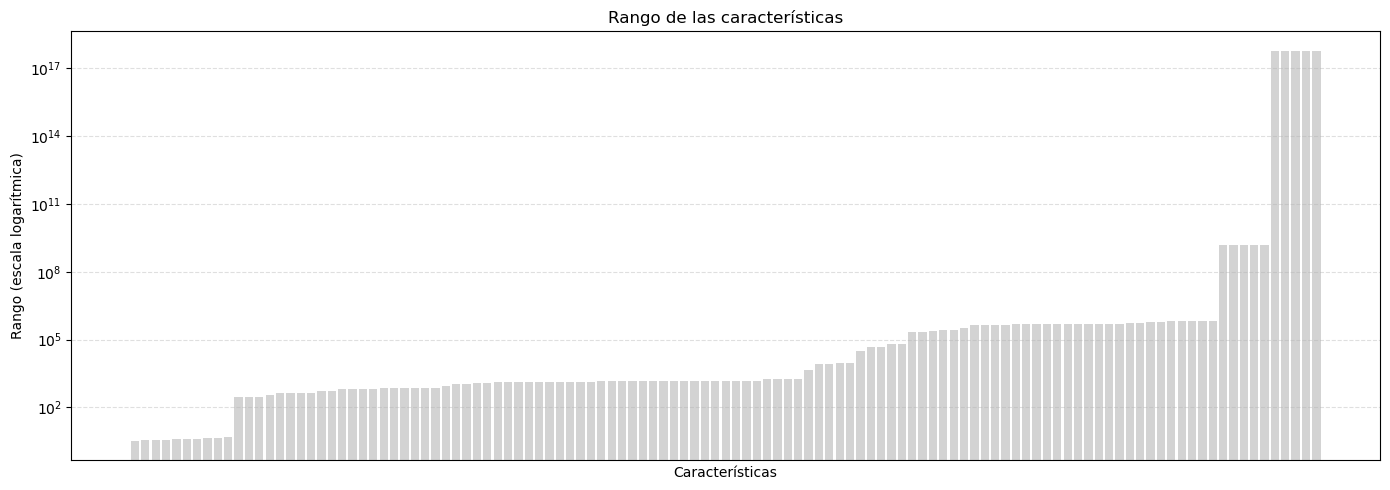

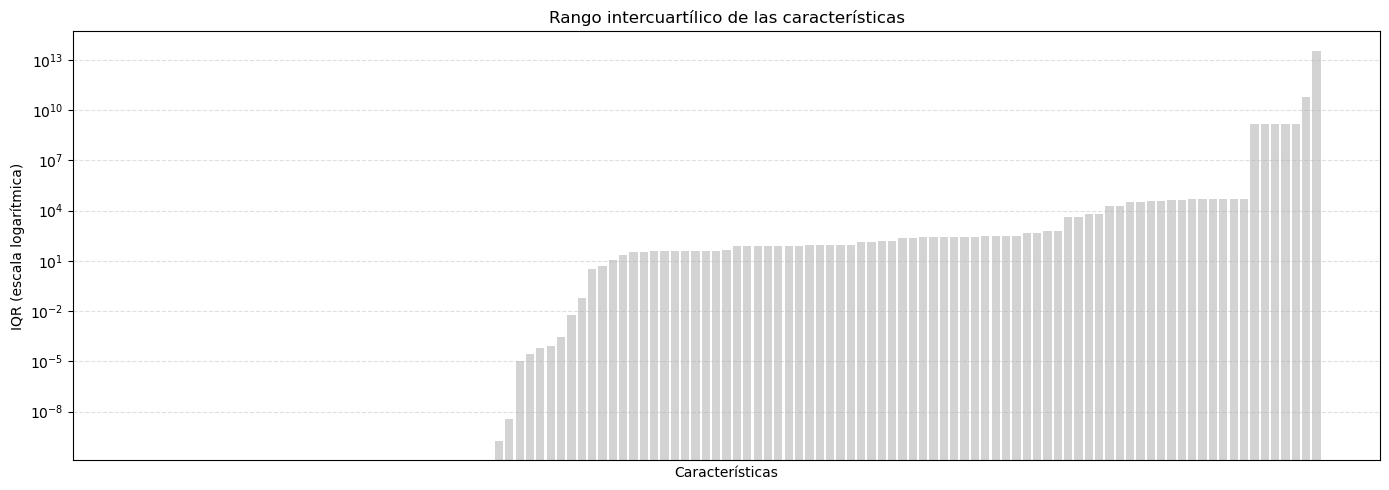

In [19]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    scale_summary_df = (
        global_sample_df[NUMERIC_COLUMNS]
        .describe()
        .T
        .reset_index()
        .rename(columns={"index": "Feature"})
    )

    scale_summary_df["Rango"] = (
        scale_summary_df["max"] - scale_summary_df["min"]
    )

    scale_summary_df["IQR"] = (
        scale_summary_df["75%"] - scale_summary_df["25%"]
    )

    range_df = (
        scale_summary_df[
            ["Feature", "min", "max", "Rango"]
        ]
        .sort_values("Rango")
        .reset_index(drop=True)
    )

    iqr_df = (
        scale_summary_df[
            ["Feature", "25%", "75%", "IQR"]
        ]
        .sort_values("IQR")
        .reset_index(drop=True)
    )
    print("ESTUDIO DEL RANGO DE LAS CARACTERÍSTICAS")
    print("Top 20 características con menor rango:")
    display(range_df.head(20))
    print("Top 20 características con mayor rango:")
    display(range_df.tail(20))

    print("ESTUDIO DEL RANGO INTERCUARTÍLICO DE LAS CARACTERÍSTICAS")
    print("Top 20 características con menor IQR:")
    display(iqr_df.head(20))
    print("Top 20 características con mayor IQR:")
    display(iqr_df.tail(20))

    plt.figure(figsize=(14, 5))

    plt.bar(
        range_df["Feature"],
        range_df["Rango"],
        color="lightgray"
    )

    plt.yscale("log")
    plt.title("Rango de las características")
    plt.xlabel("Características")
    plt.ylabel("Rango (escala logarítmica)")
    plt.xticks([])
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))

    plt.bar(
        iqr_df["Feature"],
        iqr_df["IQR"],
        color="lightgray"
    )

    plt.yscale("log")
    plt.title("Rango intercuartílico de las características")
    plt.xlabel("Características")
    plt.ylabel("IQR (escala logarítmica)")
    plt.xticks([])
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

Los resultados obtenidos confirman la hipótesis planteada en el apartado anterior. Tanto el análisis del rango como el del rango intercuartílico muestran que las características del dataset presentan diferencias de varios órdenes de magnitud en sus escalas. Además, la similitud entre ambas distribuciones indica que estas diferencias no se deben únicamente a la presencia de valores extremos, sino que forman parte del comportamiento habitual de las variables. En consecuencia, puede afirmarse que la heterogeneidad de escalas constituye una propiedad intrínseca del conjunto de características y no un efecto provocado por un reducido número de observaciones atípicas.

Este resultado tiene una implicación directa sobre el diseño del proceso de entrenamiento. En particular, algoritmos basados en distancias, como Local Outlier Factor (LOF), son especialmente sensibles a la escala de las variables, ya que aquellas con mayor magnitud pueden dominar el cálculo de las distancias y reducir la contribución del resto de características. Del mismo modo, aunque los autoencoders no dependen explícitamente de una métrica de distancia durante la inferencia, el entrenamiento de redes neuronales también se beneficia de trabajar con variables en escalas homogéneas, favoreciendo una convergencia más estable y un aprendizaje equilibrado de todas las características.

Por todo ello, se considera necesario aplicar un proceso de escalado antes del entrenamiento de ambos modelos. Entre las distintas alternativas existentes, se selecciona **StandardScaler**, ya que el análisis realizado no muestra evidencias de que las diferencias de escala estén originadas principalmente por valores extremos, circunstancia en la que métodos como **RobustScaler** resultarían más apropiados. Además, el escalador se ajustará exclusivamente utilizando las muestras benignas del conjunto de entrenamiento, lo que permite estimar de forma representativa la media y la desviación típica del comportamiento normal de la red sin introducir información procedente del tráfico malicioso.

### 2.5 Correlación entre variables

La correlación entre características permite identificar relaciones lineales entre las variables del conjunto de datos y estudiar el grado de redundancia de la información que contienen. Sin embargo, debido a la estructura jerárquica del dataset N-BaIoT, en la que cada una de las 23 características se calcula para cinco ventanas temporales distintas, analizar directamente la matriz de correlación completa resultaría poco intuitivo y dificultaría la interpretación de los resultados.

Por este motivo, el análisis se divide en 2 estudios complementarios. En primer lugar, se evalúa el grado de correlación existente entre las distintas ventanas temporales de cada característica con el objetivo de determinar si aportan información complementaria o describen esencialmente el mismo comportamiento del tráfico. Posteriormente, se estudia la correlación entre las distintas características para cada una de las 5 ventanas temporales, permitiendo analizar la estructura de dependencia existente entre las métricas del dataset sin introducir la posible redundancia derivada de las distintas escalas temporales.

In [15]:
WINDOWS = ["L5", "L3", "L1", "L0.1", "L0.01"]


def get_base_feature_name(feature_name: str) -> str:
    for window in WINDOWS:
        token = f"_{window}_"
        if token in feature_name:
            return feature_name.replace(token, "_")
    return feature_name

#### 2.5.1 Correlación entre ventanas temporales

En este subapartado se analiza, de forma independiente para cada una de las 23 características del dataset, el grado de correlación existente entre las 5 ventanas temporales empleadas durante la extracción de características. Para ello, se calcula la media de la correlación de Pearson absoluta entre todas las parejas de ventanas temporales asociadas a una misma característica. El uso del valor absoluto permite cuantificar la intensidad de la relación lineal entre las distintas escalas temporales, independientemente de si dicha relación es positiva o negativa. El objetivo es estudiar si las distintas ventanas temporales aportan información complementaria o, por el contrario, describen de forma muy similar el comportamiento del tráfico de red.

,Feature,Correlación media,Mediana,Mínimo,Q1,Q3,Máximo
0,HH_jit_variance,0.462001,0.320311,0.085505,0.148557,0.778869,0.991166
1,HH_pcc,0.583674,0.558816,0.245371,0.393749,0.772622,0.976497
2,HH_covariance,0.590336,0.601679,0.163574,0.332253,0.833261,0.974274
3,HpHp_pcc,0.825463,0.826357,0.666179,0.742784,0.911416,0.990392
4,HH_std,0.857913,0.870565,0.698671,0.771625,0.947942,0.996189
5,HH_radius,0.858664,0.878156,0.675595,0.755269,0.962769,0.997207
6,H_weight,0.872124,0.908099,0.707999,0.774258,0.957487,0.989371
7,MI_dir_weight,0.872124,0.908099,0.707999,0.774258,0.957487,0.989371
8,HpHp_covariance,0.895906,0.922860,0.761417,0.815271,0.962819,0.995766
9,HH_jit_weight,0.899942,0.947478,0.765045,0.798240,0.975909,0.996427


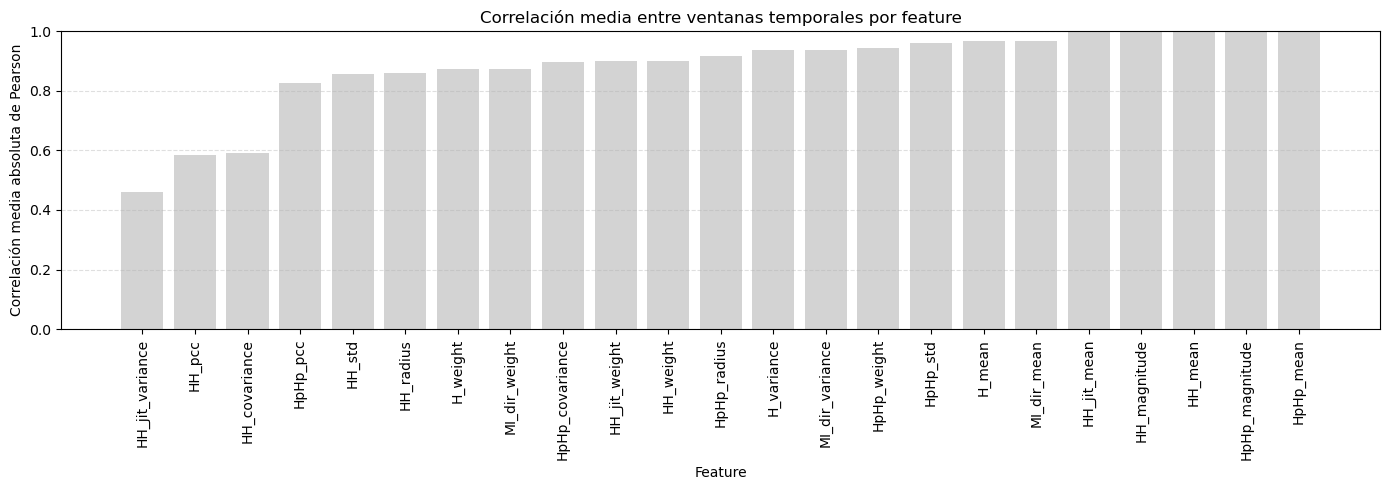

In [16]:
with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    base_features = sorted({get_base_feature_name(column)for column in NUMERIC_COLUMNS})

    temporal_correlation_rows = []

    for base_feature in base_features:

        temporal_columns = [
            column
            for column in NUMERIC_COLUMNS
            if get_base_feature_name(column) == base_feature
        ]

        temporal_columns = sorted(
            temporal_columns,
            key=lambda col: WINDOWS.index(
                next(window for window in WINDOWS if f"_{window}_" in col)
            )
        )

        corr_matrix = (
            global_sample_df[temporal_columns]
            .corr(method="pearson")
            .abs()
        )

        upper_triangle_values = (
            corr_matrix
            .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            .stack()
        )

        temporal_correlation_rows.append({
            "Feature": base_feature,
            "Correlación media": upper_triangle_values.mean(),
            "Mediana": upper_triangle_values.median(),
            "Mínimo": upper_triangle_values.min(),
            "Q1": upper_triangle_values.quantile(0.25),
            "Q3": upper_triangle_values.quantile(0.75),
            "Máximo": upper_triangle_values.max(),
        })

    temporal_correlation_df = (
        pd.DataFrame(temporal_correlation_rows)
        .sort_values("Correlación media")
        .reset_index(drop=True)
    )

    display(temporal_correlation_df)

    plt.figure(figsize=(14, 5))

    plt.bar(
        temporal_correlation_df["Feature"],
        temporal_correlation_df["Correlación media"],
        color="lightgray"
    )

    plt.title("Correlación media entre ventanas temporales por feature")
    plt.xlabel("Feature")
    plt.ylabel("Correlación media absoluta de Pearson")
    plt.ylim(0, 1)

    plt.xticks(rotation=90)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

Los resultados obtenidos muestran que la mayoría de las características presentan una elevada correlación entre las distintas ventanas temporales, lo que indica la existencia de una importante redundancia temporal en el conjunto de variables. Este comportamiento era esperable, ya que todas las ventanas describen un mismo fenómeno de tráfico observado a diferentes escalas temporales. No obstante, algunas familias de características, como las relacionadas con la varianza del *jitter*, la correlación de Pearson y la covarianza, presentan correlaciones considerablemente inferiores al resto, lo que sugiere que estas métricas son más sensibles a la ventana temporal empleada y pueden aportar información complementaria.

Estos resultados son coherentes con el análisis realizado en el apartado 2.3, donde las características asociadas a la varianza del *jitter* destacaban por presentar una variabilidad significativamente superior al resto de variables. La menor correlación observada entre sus distintas ventanas temporales refuerza la idea de que esta familia de características captura un comportamiento del tráfico especialmente dinámico, cuya representación depende en mayor medida del horizonte temporal considerado.

En consecuencia, aunque existe una elevada dependencia temporal entre muchas características, **no se considera justificado eliminar ninguna de las ventanas temporales**, ya que determinadas métricas sí parecen capturar comportamientos diferenciados según la escala temporal utilizada.

#### 2.5.2 Correlación entre características estadísticas del tráfico de red

Una vez analizada la relación existente entre las distintas ventanas temporales, en este subapartado se estudia la correlación entre las 23 características del dataset considerando cada ventana temporal por separado. De este modo, es posible identificar grupos de características que describen comportamientos similares dentro de una misma escala temporal, evitando que la existencia de múltiples representaciones temporales de una misma métrica dificulte la interpretación de los resultados.

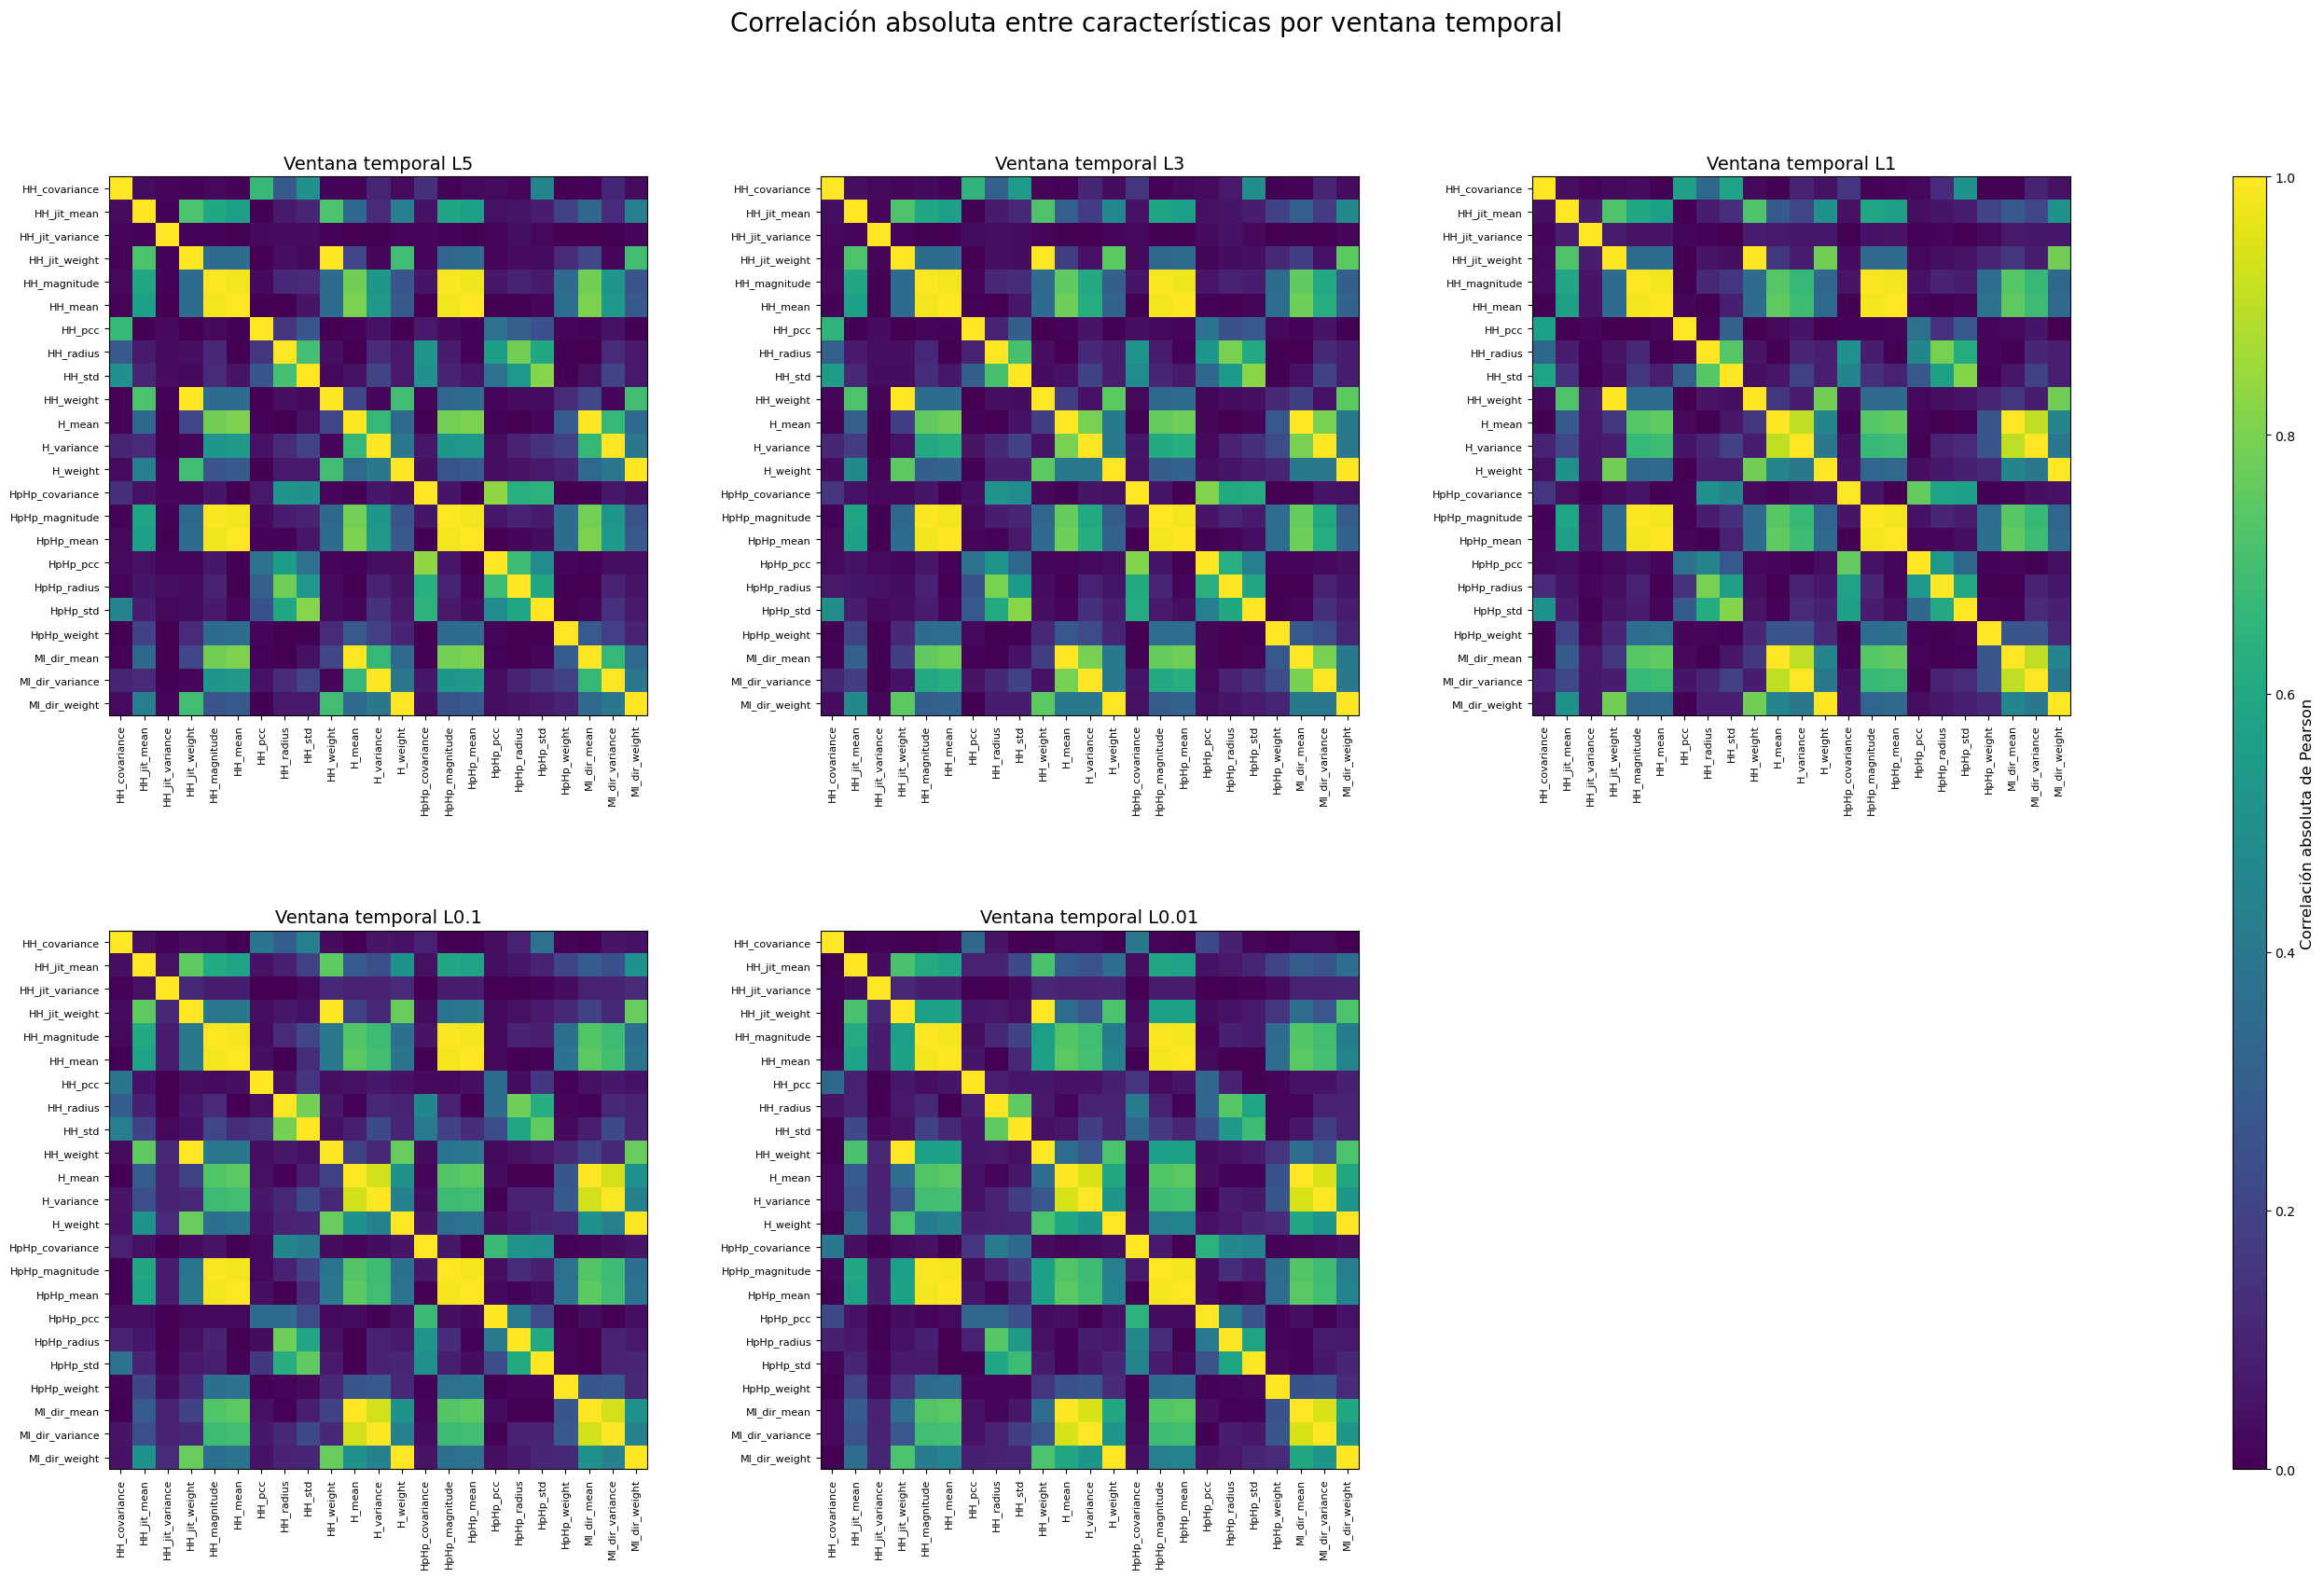

In [18]:
WINDOWS = ["L5", "L3", "L1", "L0.1", "L0.01"]

with load_parquet_temporarily(GLOBAL_SAMPLE_PATH) as global_sample_df:

    base_features = sorted({
        get_base_feature_name(column)
        for column in NUMERIC_COLUMNS
    })

    fig = plt.figure(figsize=(30, 18))

    gs = fig.add_gridspec(
        nrows=2,
        ncols=4,
        width_ratios=[1, 1, 1, 0.06],
        wspace=0.35,
        hspace=0.40,
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
    ]

    cbar_ax = fig.add_subplot(gs[:, 3])

    heatmap = None

    for idx, window in enumerate(WINDOWS):

        window_columns = [
            column
            for column in NUMERIC_COLUMNS
            if f"_{window}_" in column
        ]

        window_columns = sorted(
            window_columns,
            key=lambda col: base_features.index(
                get_base_feature_name(col)
            )
        )

        corr_matrix = (
            global_sample_df[window_columns]
            .corr(method="pearson")
            .abs()
        )

        corr_matrix.index = [
            get_base_feature_name(column)
            for column in corr_matrix.index
        ]

        corr_matrix.columns = [
            get_base_feature_name(column)
            for column in corr_matrix.columns
        ]

        heatmap = axes[idx].imshow(
            corr_matrix,
            cmap="viridis",
            vmin=0,
            vmax=1,
            aspect="equal",
        )

        axes[idx].set_title(
            f"Ventana temporal {window}",
            fontsize=14,
        )

        axes[idx].set_xticks(np.arange(len(base_features)))
        axes[idx].set_yticks(np.arange(len(base_features)))

        axes[idx].set_xticklabels(
            corr_matrix.columns,
            rotation=90,
            fontsize=8,
        )

        axes[idx].set_yticklabels(
            corr_matrix.index,
            fontsize=8,
        )

    cbar = fig.colorbar(
        heatmap,
        cax=cbar_ax,
    )

    cbar.set_label(
        "Correlación absoluta de Pearson",
        fontsize=12,
    )

    fig.suptitle(
        "Correlación absoluta entre características por ventana temporal",
        fontsize=20,
        y=0.98,
    )

    plt.show()

Las matrices de correlación obtenidas para las 5 ventanas temporales presentan una estructura muy similar, lo que indica que las relaciones existentes entre las distintas características permanecen prácticamente invariantes independientemente de la escala temporal utilizada. Asimismo, se identifican grupos de características altamente correlacionadas, reflejando que determinadas métricas describen aspectos estrechamente relacionados del comportamiento del tráfico de red. Sin embargo, dado que el objetivo de este trabajo no es realizar una selección de características, sino evaluar distintos enfoques de entrenamiento sobre el conjunto original de variables propuesto por N-BaIoT, todas las características se conservarán durante la experimentación. De este modo, los resultados obtenidos por los modelos serán directamente comparables con los trabajos previos que emplean el mismo conjunto de características.

## 3. Separabilidad de las muestras

Una vez analizada la calidad y consistencia del conjunto de datos, esta sección estudia cómo se distribuyen las muestras dentro del espacio de características. El objetivo es comprender la estructura que presenta el tráfico benigno y su relación con las distintas familias de ataque, permitiendo obtener una primera aproximación a la complejidad del problema de detección de anomalías antes del entrenamiento de los modelos.

A diferencia de la sección anterior, donde los análisis se basaban en el cálculo de estadísticos descriptivos sobre un elevado número de muestras, los métodos de reducción de dimensionalidad empleados en esta sección tienen un propósito exclusivamente exploratorio y de visualización. Por este motivo, se utilizan muestras representativas del dataset de menor tamaño, preservando la distribución original de dispositivos y tipos de tráfico. Esta estrategia permite reducir significativamente el coste computacional sin perder la estructura global del espacio de características que se desea analizar.

La sección se divide en 3 apartados:
1. Se estudia la estructura global de las muestras mediante **Análisis de Componentes Principales (PCA)**, proporcionando una primera representación lineal del espacio de características.

2. Se realiza el mismo análisis utilizando **Uniform Manifold Approximation and Projection (UMAP)**, una técnica de reducción de dimensionalidad no lineal capaz de preservar la estructura local de los datos. 

3. Se analiza la separabilidad de las muestras para cada dispositivo IoT de forma independiente, permitiendo estudiar si la estructura del espacio de características varía entre dispositivos y valorar el posible impacto de este comportamiento sobre los enfoques de entrenamiento global y por dispositivo considerados posteriormente.

In [40]:
# Muestra global para PCA y UMAP globales
sample_global_dataset(
    input_dir=PROCESSED_TEMP_PATH,
    output_dir=PROCESSED_TEMP_PATH,
    device_ids=list(range(1, 10)),
    sample_frac=VISUALIZATION_GLOBAL_SAMPLE_RATIO,
    random_state=RANDOM_STATE,
    output_filename="global_visualization_sample.parquet",
)

# Muestras por dispositivo para el análisis de separabilidad por dispositivo
for device_id in range(1, 10):
    sample_device_dataset(
        input_dir=PROCESSED_TEMP_PATH,
        output_dir=PROCESSED_TEMP_PATH,
        device_id=device_id,
        sample_frac=VISUALIZATION_DEVICE_SAMPLE_RATIO,
        random_state=RANDOM_STATE
    )

In [23]:
GLOBAL_VISUALIZATION_SAMPLE_PATH = Path(PROCESSED_TEMP_PATH) / "global_visualization_sample.parquet"

DEVICE_VISUALIZATION_SAMPLE_PATHS = [Path(PROCESSED_TEMP_PATH) / f"device_{device_id}_sample.parquet"for device_id in range(1, 10)]

In [27]:
CLASS_COLORS = {
    "benign": "cornflowerblue",
    "gafgyt": "#CD5C5C",
    "mirai": "#8B0000",
}

CLASS_LABELS = {
    "benign": "Benigno",
    "gafgyt": "Gafgyt",
    "mirai": "Mirai",
}

### 3.1 Separabilidad global mediante PCA

En este apartado se aplica PCA sobre la muestra global de visualización con el objetivo de obtener una primera representación bidimensional del espacio de características. PCA permite proyectar los datos sobre las direcciones lineales de máxima varianza, por lo que resulta útil para estudiar si existe una separación global entre el tráfico benigno y las dos familias de ataque consideradas: `gafgyt` y `mirai`.

Antes de aplicar PCA, las características se escalan mediante `StandardScaler`, de acuerdo con lo justificado en el apartado anterior. Este paso es necesario porque PCA es sensible a la escala de las variables, ya que las componentes principales se calculan a partir de la varianza de las características.

Este análisis tiene un propósito exploratorio: no se utiliza PCA como técnica de preprocesamiento para los modelos, sino como herramienta de visualización para estudiar la estructura global del dataset.

,Componente,Varianza explicada,Varianza explicada (%)
0,PC1,0.346147,34.614727
1,PC2,0.158886,15.888612


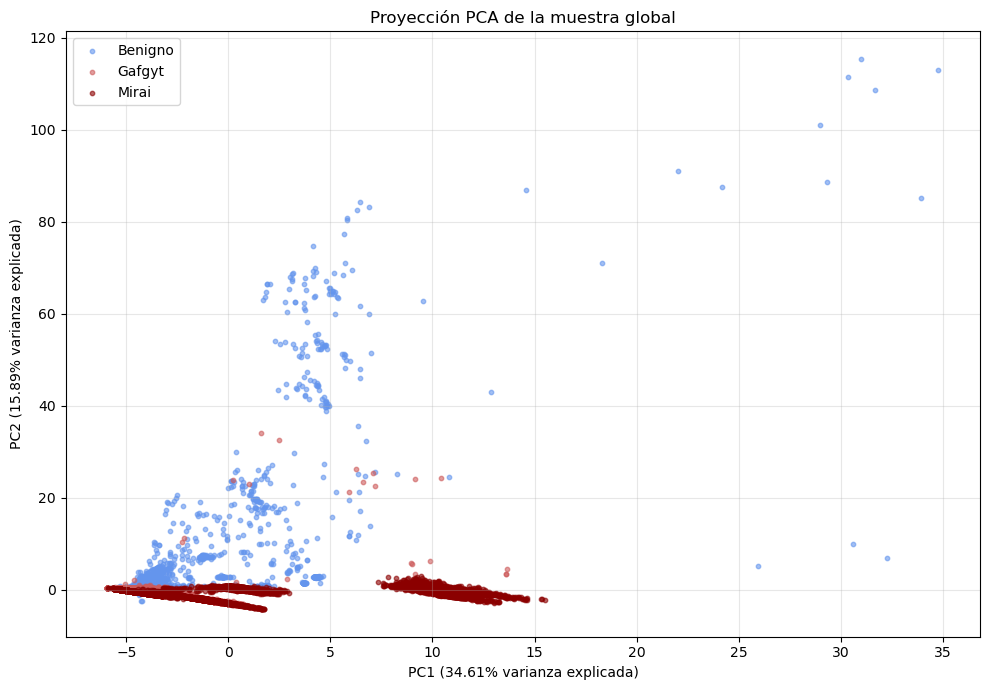

In [31]:
with load_parquet_temporarily(GLOBAL_VISUALIZATION_SAMPLE_PATH) as global_vis_df:

    X = global_vis_df[NUMERIC_COLUMNS]
    y = global_vis_df["attack_family"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "attack_family": y.values,
    })

    explained_variance_df = pd.DataFrame({
        "Componente": ["PC1", "PC2"],
        "Varianza explicada": pca.explained_variance_ratio_,
        "Varianza explicada (%)": pca.explained_variance_ratio_ * 100,
    })

    display(explained_variance_df)

    plt.figure(figsize=(10, 7))

    for attack_family in ["benign", "gafgyt", "mirai"]:

        class_df = pca_df[
            pca_df["attack_family"] == attack_family
        ]

        plt.scatter(
            class_df["PC1"],
            class_df["PC2"],
            s=10,
            alpha=0.6,
            color=CLASS_COLORS[attack_family],
            label=CLASS_LABELS[attack_family],
            rasterized=True,
        )

    plt.title("Proyección PCA de la muestra global")
    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% varianza explicada)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% varianza explicada)"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

La proyección obtenida mediante PCA muestra que las 2 primeras componentes principales son capaces de capturar una parte importante de la variabilidad del conjunto de datos, permitiendo visualizar diferencias claras entre las distintas familias de tráfico. En particular, las muestras pertenecientes a las familias de ataque *Mirai* y *Gafgyt* aparecen concentradas en regiones relativamente compactas del espacio proyectado, mientras que el tráfico benigno presenta una distribución considerablemente más dispersa y heterogénea.

Este comportamiento sugiere que el tráfico normal no constituye una única distribución homogénea, sino que podría estar formado por distintos subgrupos con características diferenciadas. Una posible explicación es que dichos grupos estén asociados al comportamiento específico de cada dispositivo IoT, ya que cada uno genera patrones de tráfico propios incluso durante su funcionamiento normal. No obstante, esta hipótesis no puede confirmarse únicamente a partir de esta representación global.

Dado que el objetivo de este trabajo es desarrollar un sistema de detección de anomalías capaz de operar sobre el conjunto de dispositivos de una red IoT, resulta especialmente relevante determinar si esta aparente heterogeneidad del tráfico benigno puede dificultar el aprendizaje de un único modelo global. Por este motivo, en el apartado **3.3** se analizará la separabilidad de las muestras para cada dispositivo de forma independiente con el fin de comprobar si la estructura observada en esta representación global está realmente condicionada por el dispositivo al que pertenecen las muestras.

### 3.2 Separabilidad global mediante UMAP

En este apartado se estudia la estructura del espacio de características mediante **Uniform Manifold Approximation and Projection (UMAP)**. A diferencia de PCA, que realiza una proyección lineal maximizando la varianza explicada, UMAP es una técnica de reducción de dimensionalidad no lineal diseñada para preservar las relaciones de vecindad entre las muestras. Como consecuencia, suele proporcionar representaciones más fieles de la estructura local del conjunto de datos y facilitar la identificación de agrupaciones naturales.

Al igual que en el apartado anterior, las características se escalan previamente mediante `StandardScaler` y se emplean los parámetros por defecto de UMAP (`n_neighbors=15` y `min_dist=0.1`), ya que el objetivo de este análisis es exclusivamente exploratorio y no la optimización del algoritmo. La pregunta que se pretende responder es si la preservación de la estructura local permite identificar patrones o agrupaciones que no resultaban evidentes mediante PCA y, en particular, si la organización del tráfico benigno y de las distintas familias de ataque proporciona información adicional para interpretar posteriormente el comportamiento de los modelos de detección de anomalías.

In [32]:
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1

/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


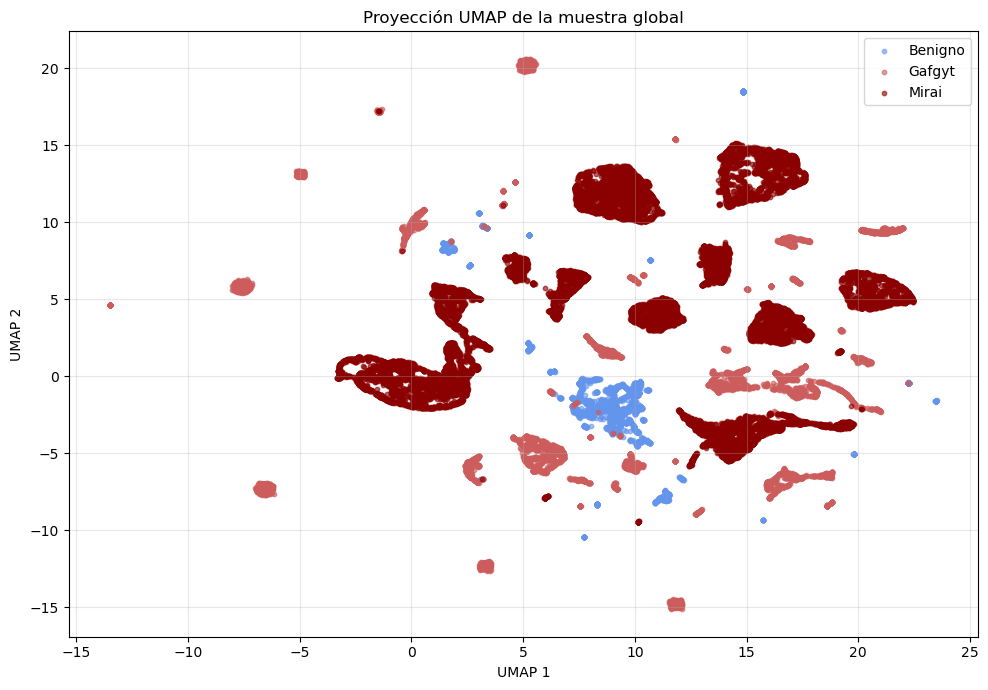

In [34]:
with load_parquet_temporarily(GLOBAL_VISUALIZATION_SAMPLE_PATH) as global_vis_df:

    X = global_vis_df[NUMERIC_COLUMNS]
    y = global_vis_df["attack_family"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )

    X_umap = reducer.fit_transform(X_scaled)

    umap_df = pd.DataFrame({
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "attack_family": y.values,
    })

    plt.figure(figsize=(10, 7))

    for attack_family in ["benign", "gafgyt", "mirai"]:

        class_df = umap_df[
            umap_df["attack_family"] == attack_family
        ]

        plt.scatter(
            class_df["UMAP1"],
                        class_df["UMAP2"],
            s=10,
            alpha=0.6,
            color=CLASS_COLORS[attack_family],
            label=CLASS_LABELS[attack_family],
            rasterized=True,
        )

    plt.title("Proyección UMAP de la muestra global")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

La representación obtenida mediante UMAP muestra una estructura significativamente más rica que la observada con PCA. Al preservar las relaciones de vecindad entre las muestras, el algoritmo identifica numerosos grupos compactos distribuidos a lo largo del espacio proyectado, evidenciando que el conjunto de datos presenta una estructura local compleja que no podía apreciarse mediante una proyección lineal.

A diferencia de PCA, donde las familias de ataque aparecían relativamente concentradas en una única región del espacio, UMAP revela que tanto **Mirai** como **Gafgyt** están formadas por múltiples agrupaciones claramente diferenciadas. Este comportamiento resulta coherente con la propia construcción del dataset, ya que cada familia engloba distintos tipos de ataque que generan patrones de tráfico con características diferentes.

Por otra parte, el tráfico benigno continúa presentando una distribución heterogénea. Aunque gran parte de las muestras benignas se concentran en una región relativamente compacta, también se observan grupos dispersos y zonas donde existe cierto grado de proximidad con muestras de ataque. Esto sugiere que la estructura del tráfico normal es considerablemente más compleja de lo que podría deducirse a partir de una representación lineal.

En conjunto, estos resultados confirman que el espacio de características de N-BaIoT posee una estructura fuertemente no lineal. Además, refuerzan la hipótesis planteada en el apartado anterior de que parte de la heterogeneidad observada en el tráfico benigno podría estar relacionada con el dispositivo IoT al que pertenecen las muestras. Esta hipótesis será analizada en el siguiente apartado mediante el estudio independiente de cada dispositivo.

### 3.3 Estructura local del espacio de características por dispositivo

En los apartados anteriores se ha estudiado la estructura global del conjunto de datos utilizando representaciones obtenidas mediante PCA y UMAP. Sin embargo, dichas representaciones combinan simultáneamente las muestras de todos los dispositivos IoT, por lo que la heterogeneidad observada en el tráfico benigno podría estar condicionada por las diferencias existentes entre ellos.

Con el objetivo de comprobar esta hipótesis, en este apartado se aplica UMAP de forma independiente sobre cada uno de los dispositivos del dataset, representando conjuntamente las muestras benignas y las correspondientes a las familias de ataque **Gafgyt** y **Mirai**. Al tratarse de representaciones obtenidas de manera independiente, no deben compararse las posiciones absolutas de los grupos entre distintos dispositivos, ya que UMAP únicamente preserva la estructura local del espacio de características. En consecuencia, el interés del análisis se centra en estudiar la forma, compacidad y grado de solapamiento de las distintas agrupaciones dentro de cada dispositivo, y no en la posición que ocupan en la representación bidimensional.

Este análisis permitirá comprobar si la heterogeneidad observada previamente en el tráfico benigno desaparece al estudiar cada dispositivo por separado, proporcionando una primera evidencia sobre la dificultad que puede suponer entrenar un único modelo global frente a modelos específicos para cada dispositivo.

/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pablo/miniconda3/envs/master-tfm/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/

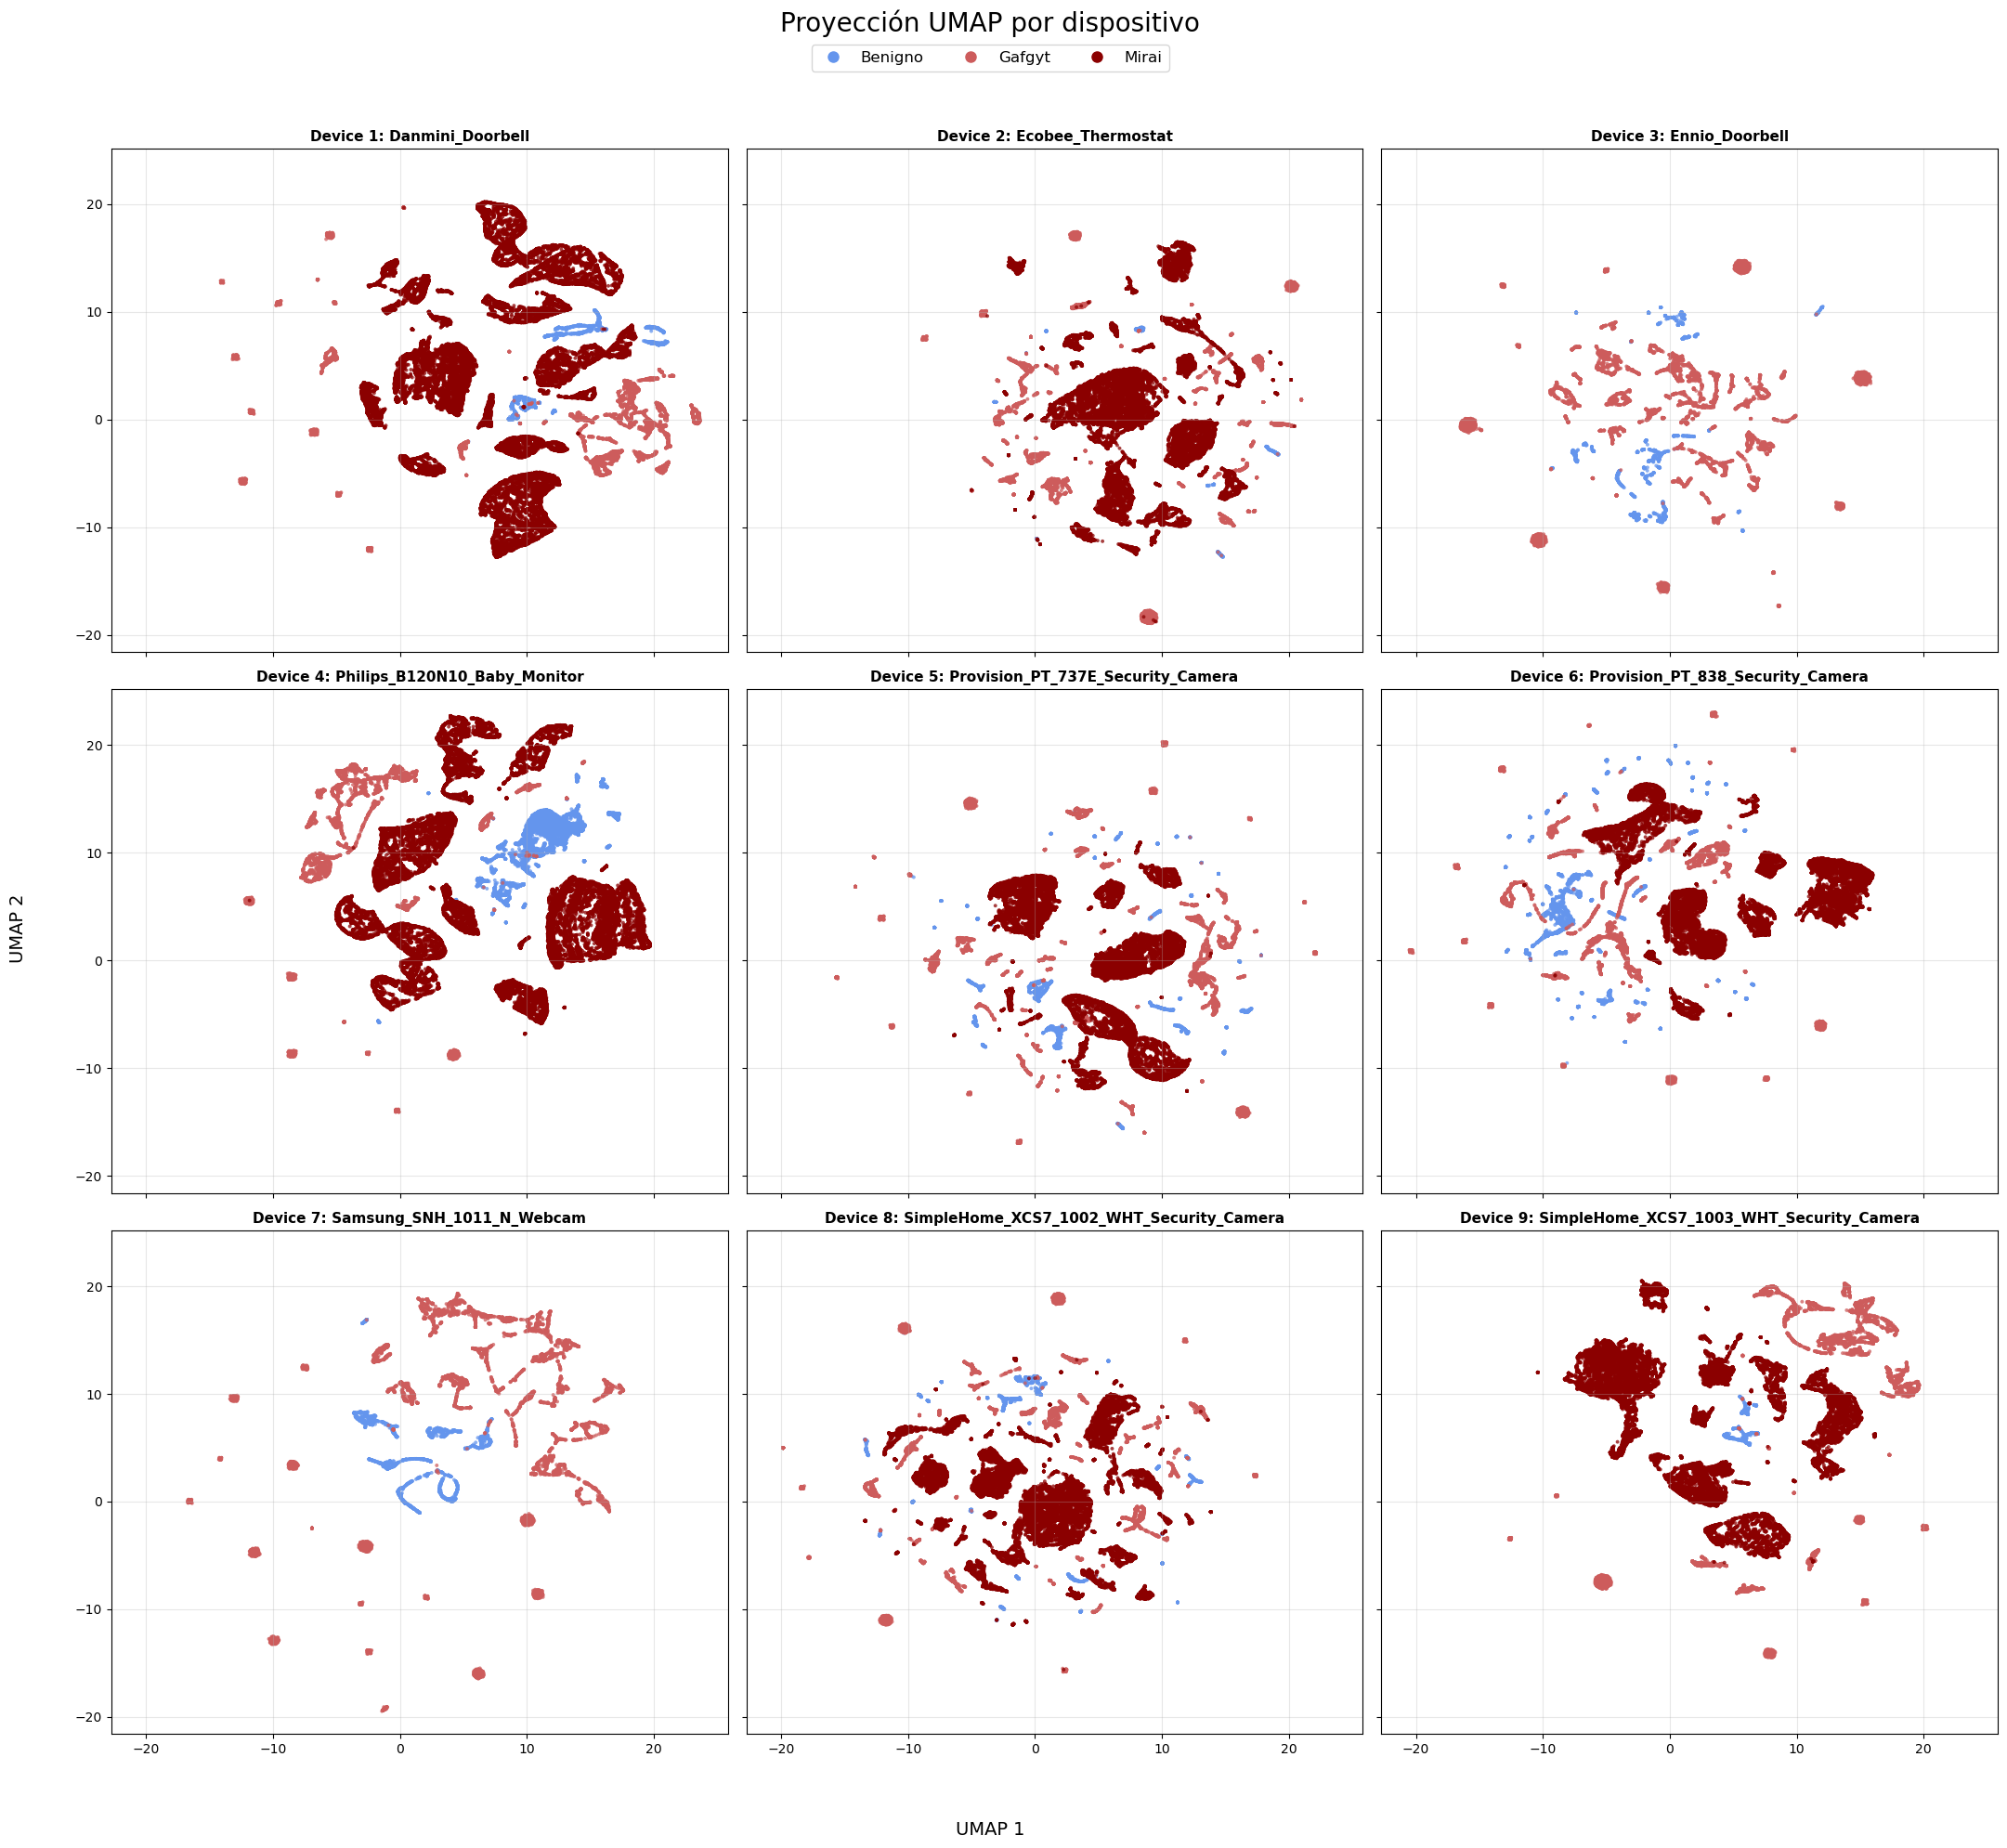

In [41]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(22, 20),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for device_id, sample_path in enumerate(
    DEVICE_VISUALIZATION_SAMPLE_PATHS,
    start=1
):

    with load_parquet_temporarily(sample_path) as device_sample_df:

        X = device_sample_df[NUMERIC_COLUMNS]
        y = device_sample_df["attack_family"]

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric="euclidean",
            random_state=RANDOM_STATE,
        )

        X_umap = reducer.fit_transform(X_scaled)

        umap_df = pd.DataFrame({
            "UMAP1": X_umap[:, 0],
            "UMAP2": X_umap[:, 1],
            "attack_family": y.values,
        })

        ax = axes[device_id - 1]

        for attack_family in ["benign", "gafgyt", "mirai"]:

            class_df = umap_df[
                umap_df["attack_family"] == attack_family
            ]

            ax.scatter(
                class_df["UMAP1"],
                class_df["UMAP2"],
                s=8,
                alpha=0.75,
                color=CLASS_COLORS[attack_family],
                edgecolors="none",
                rasterized=True,
            )

        device_name = device_df.loc[
            device_df["DeviceID"] == device_id,
            "DeviceName"
        ].iloc[0]

        ax.set_title(
            f"Device {device_id}: {device_name}",
            fontsize=11,
            fontweight="bold",
        )

        ax.grid(alpha=0.3)

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=CLASS_COLORS[attack_family],
        markersize=8,
        label=CLASS_LABELS[attack_family],
    )
    for attack_family in ["benign", "gafgyt", "mirai"]
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=True,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.98),
)

fig.suptitle(
    "Proyección UMAP por dispositivo",
    fontsize=20,
    y=0.995,
)

fig.supxlabel("UMAP 1", fontsize=14)
fig.supylabel("UMAP 2", fontsize=14)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])

plt.show()

La representación obtenida mediante UMAP muestra que la estructura local del espacio de características presenta diferencias apreciables entre los distintos dispositivos IoT. Tal y como se indicó al inicio del apartado, las posiciones absolutas de las agrupaciones no son comparables entre figuras, ya que cada representación se ha obtenido de manera independiente. En consecuencia, el análisis se centra en la forma de las agrupaciones y en el grado de separación existente entre el tráfico benigno y las distintas familias de ataque.

En primer lugar, no se observa una evidencia concluyente que permita afirmar que la heterogeneidad del tráfico benigno observada en las representaciones globales desaparezca completamente al analizar cada dispositivo por separado. Aunque algunos dispositivos presentan agrupaciones benignas relativamente compactas, otros continúan mostrando una estructura más dispersa, lo que sugiere que parte de la variabilidad del tráfico normal es intrínseca al propio comportamiento de determinados dispositivos y no únicamente consecuencia de combinar información procedente de múltiples dispositivos.

Por otra parte, también se aprecia que la dificultad del problema no es uniforme entre dispositivos. En algunos casos las muestras benignas aparecen claramente separadas de las distintas familias de ataque, mientras que en otros la proximidad entre ambas resulta considerablemente mayor. Esta observación sugiere que la capacidad de un detector de anomalías para diferenciar tráfico normal y malicioso puede depender en cierta medida del dispositivo monitorizado.

Finalmente, es importante tener en cuenta que la interpretación de estas representaciones está condicionada por la distribución de clases del propio dataset. Tal y como se mostró en el apartado **1.2**, algunos dispositivos disponen de un número muy reducido de muestras benignas en comparación con las muestras de ataque. En estos casos, la representación del tráfico benigno resulta necesariamente menos informativa y dificulta la identificación de posibles agrupaciones, por lo que las diferencias observadas entre dispositivos deben interpretarse considerando también esta limitación del conjunto de datos.

En conjunto, este análisis pone de manifiesto que el diseño de un detector global de anomalías para redes IoT debe afrontar una elevada heterogeneidad tanto entre dispositivos como en la estructura del propio tráfico benigno. Esta complejidad constituye uno de los principales desafíos del problema y servirá de contexto para interpretar posteriormente las diferencias de rendimiento observadas entre los modelos entrenados de forma global y aquellos entrenados específicamente para cada dispositivo.

## Conclusiones del EDA

El análisis exploratorio realizado sobre el dataset N-BaIoT ha permitido caracterizar en profundidad tanto la calidad de los datos como la estructura estadística del problema de detección de anomalías, proporcionando la información necesaria para diseñar la experimentación desarrollada en este trabajo.

En primer lugar, el estudio de la distribución de las muestras ha puesto de manifiesto un fuerte desbalance entre tráfico benigno y tráfico de ataque, así como diferencias importantes en el número de muestras disponibles para cada dispositivo. A partir de esta observación se decidió mantener la distribución original del dataset durante el entrenamiento y la evaluación de los modelos, reservando el estudio de escenarios con distribuciones más próximas a un entorno real para el análisis de resultados, evitando así introducir sesgos artificiales durante la fase experimental.

El análisis de calidad de los datos confirmó la ausencia de valores faltantes y de características constantes, descartando la necesidad de aplicar técnicas de imputación o eliminación de variables. Por el contrario, el estudio de la redundancia evidenció que el porcentaje de muestras duplicadas depende directamente del escenario considerado. Mientras que el entrenamiento específico por dispositivo presenta una redundancia reducida, el entrenamiento global incorpora un elevado número de observaciones idénticas procedentes de distintos dispositivos. Este resultado permitió interpretar correctamente la naturaleza del dataset y proporcionó un contexto adecuado para analizar posteriormente las diferencias de rendimiento entre ambos enfoques de entrenamiento.

Por otra parte, el análisis de la varianza, las escalas y la correlación entre características mostró que las variables presentan órdenes de magnitud muy diferentes y fuertes dependencias estadísticas. Estos resultados justificaron la incorporación de un proceso de normalización mediante StandardScaler como etapa previa al entrenamiento de todos los modelos, garantizando que ninguna característica domine el aprendizaje únicamente debido a su escala.

Finalmente, el estudio de la estructura del espacio de características mediante PCA y UMAP puso de manifiesto que el problema presenta un comportamiento claramente no lineal y una elevada heterogeneidad tanto entre dispositivos como dentro del propio tráfico benigno. El análisis por dispositivo mostró que dicha heterogeneidad no desaparece completamente al estudiar cada dispositivo de forma independiente, lo que sugiere que la complejidad del problema no proviene únicamente de combinar distintos dispositivos, sino también del comportamiento intrínseco de cada uno de ellos. Esta observación justifica el interés de comparar experimentalmente un enfoque basado en modelos específicos por dispositivo frente a un modelo global capaz de generalizar al conjunto de la red.

En conjunto, el EDA ha permitido fundamentar las principales decisiones metodológicas adoptadas durante la experimentación, entre las que destacan la utilización de un proceso de normalización previo al entrenamiento, el mantenimiento de la distribución original de las muestras, el análisis diferenciado de los escenarios de entrenamiento global y específico por dispositivo y la interpretación de los resultados considerando la elevada heterogeneidad estructural del dataset. De este modo, la fase experimental que se desarrolla a continuación parte de un conocimiento detallado de las características y limitaciones del conjunto de datos, favoreciendo una evaluación más rigurosa y una interpretación más sólida de los resultados obtenidos.